# BÁO CÁO THỰC HÀNH: THUẬT TOÁN K-MEANS VÀ FUZZY C-MEANS (FCM)
**Học phần:** Học máy (Machine Learning) - Lab 02  
**Chủ đề:** Thuật toán phân cụm K-Means & Fuzzy C-Means (Clustering Algorithms)  

**Thông tin sinh viên:**
- **Họ và tên:** Nguyễn Đỗ Thắng  
- **Lớp:** 23T_NHAT1  
- **MSSV:** 102230046  

---

## 1. TỔNG QUAN BÀI TOÁN VÀ DỮ LIỆU ĐẦU VÀO

Cho tập dữ liệu gồm $N = 8$ sinh viên, mỗi sinh viên được biểu diễn bằng một điểm dữ liệu 2 chiều $(x, y)$ đại diện cho **Tuổi (Age - $x$)** và **Điểm số (Marks - $y$)**:

| Sinh viên | Tuổi ($x$) | Điểm ($y$) |
|:---:|:---:|:---:|
| $S_1$ | 5 | 10 |
| $S_2$ | 6 | 8 |
| $S_3$ | 4 | 5 |
| $S_4$ | 7 | 10 |
| $S_5$ | 8 | 12 |
| $S_6$ | 10 | 9 |
| $S_7$ | 12 | 11 |
| $S_8$ | 4 | 6 |

**Các tâm cụm ban đầu:**
- $\mu_1 = C_1 = S_1(5, 10)$
- $\mu_2 = C_2 = S_4(7, 10)$
- $\mu_3 = C_3 = S_7(12, 11)$


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Cau hinh hien thi do hoa
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

# Khoi tao du lieu
data = np.array([
    [5, 10], # S1
    [6, 8],  # S2
    [4, 5],  # S3
    [7, 10], # S4
    [8, 12], # S5
    [10, 9], # S6
    [12, 11],# S7
    [4, 6]   # S8
], dtype=float)

student_names = [f'S{i+1}' for i in range(len(data))]
initial_centroids = np.array([[5.0, 10.0], [7.0, 10.0], [12.0, 11.0]])

print("Du lieu 8 sinh vien:\n", pd.DataFrame(data, index=student_names, columns=['Age (x)', 'Marks (y)']))
print("\nTam cum ban dau:\n", pd.DataFrame(initial_centroids, index=['Cluster 1', 'Cluster 2', 'Cluster 3'], columns=['x', 'y']))


Du lieu 8 sinh vien:
     Age (x)  Marks (y)
S1      5.0       10.0
S2      6.0        8.0
S3      4.0        5.0
S4      7.0       10.0
S5      8.0       12.0
S6     10.0        9.0
S7     12.0       11.0
S8      4.0        6.0

Tam cum ban dau:
               x     y
Cluster 1   5.0  10.0
Cluster 2   7.0  10.0
Cluster 3  12.0  11.0


---
# BÀI 1: THUẬT TOÁN K-MEANS (EXERCISE 01)

### Cơ sở lý thuyết & Công thức toán học

Thuật toán K-Means phân chia $N$ điểm dữ liệu vào $K$ cụm sao cho tổng bình phương khoảng cách giữa các điểm và tâm cụm tương ứng là nhỏ nhất (Hàm mục tiêu $J$):
$$J = \sum_{k=1}^K \sum_{x \in S_k} d^2(x, \mu_k)$$

Thuật toán gồm hai bước lặp chính:
1. **Bước gán cụm (Assignment Step):** Gán mỗi điểm dữ liệu $x_j$ vào cụm có tâm gần nhất:
   $$c(j) = \arg\min_{k \in \{1, \dots, K\}} d(x_j, \mu_k)$$
   *Quy ước:* Nếu khoảng cách tới 2 tâm bằng nhau, ưu tiên gán vào cụm có chỉ số nhỏ hơn.

2. **Bước cập nhật tâm cụm (Update Step):** Tính lại tọa độ tâm cụm bằng trung bình cộng các điểm thuộc cụm:
   $$\mu_k = \frac{1}{|S_k|} \sum_{x \in S_k} x$$

**Các độ đo khoảng cách:**
- **Khoảng cách Manhattan ($L_1$ norm):**
  $$d_M(x, \mu) = |x_1 - \mu_1| + |x_2 - \mu_2|$$
- **Khoảng cách Euclidean ($L_2$ norm):**
  $$d_E(x, \mu) = \sqrt{(x_1 - \mu_1)^2 + (x_2 - \mu_2)^2}$$


## 1.a. Thực hiện phân cụm K-Means với khoảng cách Manhattan

Tâm ban đầu: $\mu_1 = (5, 10)$, $\mu_2 = (7, 10)$, $\mu_3 = (12, 11)$

### Vòng lặp 1 (Iteration 1)
Tâm cụm: $\mu_1(5, 10)$, $\mu_2(7, 10)$, $\mu_3(12, 11)$

**Bảng tính khoảng cách và gán cụm (Iteration 1):**

| No | Age | Marks | Dist Mean 1 (5, 10) | Dist Mean 2 (7, 10) | Dist Mean 3 (12, 11) | Cluster |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| $S_1$ | 5 | 10 | $|5-5|+|10-10| = \mathbf{0}$ | $|5-7|+|10-10| = 2$ | $|5-12|+|10-11| = 8$ | **Cluster 1** |
| $S_2$ | 6 | 8 | $|6-5|+|8-10| = \mathbf{3}$ | $|6-7|+|8-10| = 3$ | $|6-12|+|8-11| = 9$ | **Cluster 1** *(tie-break)* |
| $S_3$ | 4 | 5 | $|4-5|+|5-10| = \mathbf{6}$ | $|4-7|+|5-10| = 8$ | $|4-12|+|5-11| = 14$ | **Cluster 1** |
| $S_4$ | 7 | 10 | $|7-5|+|10-10| = 2$ | $|7-7|+|10-10| = \mathbf{0}$ | $|7-12|+|10-11| = 6$ | **Cluster 2** |
| $S_5$ | 8 | 12 | $|8-5|+|12-10| = 5$ | $|8-7|+|12-10| = \mathbf{3}$ | $|8-12|+|12-11| = 5$ | **Cluster 2** |
| $S_6$ | 10 | 9 | $|10-5|+|9-10| = 6$ | $|10-7|+|9-10| = \mathbf{4}$ | $|10-12|+|9-11| = 4$ | **Cluster 2** *(tie-break)* |
| $S_7$ | 12 | 11 | $|12-5|+|11-10| = 8$ | $|12-7|+|11-10| = 6$ | $|12-12|+|11-11| = \mathbf{0}$ | **Cluster 3** |
| $S_8$ | 4 | 6 | $|4-5|+|6-10| = \mathbf{5}$ | $|4-7|+|6-10| = 7$ | $|4-12|+|6-11| = 13$ | **Cluster 1** |

**Cập nhật tâm cụm sau Vòng lặp 1:**
- **Cụm 1** gồm $\{S_1, S_2, S_3, S_8\}$:
  $$\mu_1^{(1)} = \left(\frac{5 + 6 + 4 + 4}{4}, \frac{10 + 8 + 5 + 6}{4}\right) = \left(\frac{19}{4}, \frac{29}{4}\right) = (4.75, 7.25)$$
- **Cụm 2** gồm $\{S_4, S_5, S_6\}$:
  $$\mu_2^{(1)} = \left(\frac{7 + 8 + 10}{3}, \frac{10 + 12 + 9}{3}\right) = \left(\frac{25}{3}, \frac{31}{3}\right) \approx (8.33, 10.33)$$
- **Cụm 3** gồm $\{S_7\}$:
  $$\mu_3^{(1)} = (12.00, 11.00)$$

---

### Vòng lặp 2 (Iteration 2)
Tâm cụm mới: $\mu_1(4.75, 7.25)$, $\mu_2(8.33, 10.33)$, $\mu_3(12, 11)$

**Bảng tính khoảng cách và gán cụm (Iteration 2):**

| No | Age | Marks | Dist Mean 1 (4.75, 7.25) | Dist Mean 2 (8.33, 10.33) | Dist Mean 3 (12, 11) | Cluster |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| $S_1$ | 5 | 10 | $|5-4.75|+|10-7.25| = \mathbf{3.00}$ | $|5-8.33|+|10-10.33| = 3.67$ | $|5-12|+|10-11| = 8.00$ | **Cluster 1** |
| $S_2$ | 6 | 8 | $|6-4.75|+|8-7.25| = \mathbf{2.00}$ | $|6-8.33|+|8-10.33| = 4.67$ | $|6-12|+|8-11| = 9.00$ | **Cluster 1** |
| $S_3$ | 4 | 5 | $|4-4.75|+|5-7.25| = \mathbf{3.00}$ | $|4-8.33|+|5-10.33| = 9.67$ | $|4-12|+|5-11| = 14.00$ | **Cluster 1** |
| $S_4$ | 7 | 10 | $|7-4.75|+|10-7.25| = 5.00$ | $|7-8.33|+|10-10.33| = \mathbf{1.67}$ | $|7-12|+|10-11| = 6.00$ | **Cluster 2** |
| $S_5$ | 8 | 12 | $|8-4.75|+|12-7.25| = 8.00$ | $|8-8.33|+|12-10.33| = \mathbf{2.00}$ | $|8-12|+|12-11| = 5.00$ | **Cluster 2** |
| $S_6$ | 10 | 9 | $|10-4.75|+|9-7.25| = 7.00$ | $|10-8.33|+|9-10.33| = \mathbf{3.00}$ | $|10-12|+|9-11| = 4.00$ | **Cluster 2** |
| $S_7$ | 12 | 11 | $|12-4.75|+|11-7.25| = 11.00$ | $|12-8.33|+|11-10.33| = 4.33$ | $|12-12|+|11-11| = \mathbf{0.00}$ | **Cluster 3** |
| $S_8$ | 4 | 6 | $|4-4.75|+|6-7.25| = \mathbf{2.00}$ | $|4-8.33|+|6-10.33| = 8.67$ | $|4-12|+|6-11| = 13.00$ | **Cluster 1** |

**Cập nhật tâm cụm sau Vòng lặp 2:**
- Việc gán cụm ở Vòng lặp 2 hoàn toàn trùng khớp với Vòng lặp 1:
  - Cụm 1: $\{S_1, S_2, S_3, S_8\} \implies \mu_1^{(2)} = (4.75, 7.25)$
  - Cụm 2: $\{S_4, S_5, S_6\} \implies \mu_2^{(2)} = (8.33, 10.33)$
  - Cụm 3: $\{S_7\} \implies \mu_3^{(2)} = (12.00, 11.00)$
- **Kết luận:** Tọa độ các tâm cụm không thay đổi ($\mu^{(2)} = \mu^{(1)}$). Thuật toán K-Means với khoảng cách Manhattan **hội tụ sau 2 vòng lặp**.


## 1.b. Thực hiện phân cụm K-Means với khoảng cách Euclidean

Tâm ban đầu: $\mu_1 = (5, 10)$, $\mu_2 = (7, 10)$, $\mu_3 = (12, 11)$

### Vòng lặp 1 (Iteration 1)
Tâm cụm: $\mu_1(5, 10)$, $\mu_2(7, 10)$, $\mu_3(12, 11)$

**Bảng tính khoảng cách và gán cụm (Iteration 1):**

| No | Age | Marks | Dist Mean 1 (5, 10) | Dist Mean 2 (7, 10) | Dist Mean 3 (12, 11) | Cluster |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| $S_1$ | 5 | 10 | $\sqrt{0^2 + 0^2} = \mathbf{0.0000}$ | $\sqrt{(-2)^2 + 0^2} = 2.0000$ | $\sqrt{(-7)^2 + (-1)^2} = 7.0711$ | **Cluster 1** |
| $S_2$ | 6 | 8 | $\sqrt{1^2 + (-2)^2} = \mathbf{2.2361}$ | $\sqrt{(-1)^2 + (-2)^2} = 2.2361$ | $\sqrt{(-6)^2 + (-3)^2} = 6.7082$ | **Cluster 1** *(tie-break)* |
| $S_3$ | 4 | 5 | $\sqrt{(-1)^2 + (-5)^2} = \mathbf{5.0990}$ | $\sqrt{(-3)^2 + (-5)^2} = 5.8310$ | $\sqrt{(-8)^2 + (-6)^2} = 10.0000$ | **Cluster 1** |
| $S_4$ | 7 | 10 | $\sqrt{2^2 + 0^2} = 2.0000$ | $\sqrt{0^2 + 0^2} = \mathbf{0.0000}$ | $\sqrt{(-5)^2 + (-1)^2} = 5.0990$ | **Cluster 2** |
| $S_5$ | 8 | 12 | $\sqrt{3^2 + 2^2} = 3.6056$ | $\sqrt{1^2 + 2^2} = \mathbf{2.2361}$ | $\sqrt{(-4)^2 + 1^2} = 4.1231$ | **Cluster 2** |
| $S_6$ | 10 | 9 | $\sqrt{5^2 + (-1)^2} = 5.0990$ | $\sqrt{3^2 + (-1)^2} = 3.1623$ | $\sqrt{(-2)^2 + (-2)^2} = \mathbf{2.8284}$ | **Cluster 3** |
| $S_7$ | 12 | 11 | $\sqrt{7^2 + 1^2} = 7.0711$ | $\sqrt{5^2 + 1^2} = 5.0990$ | $\sqrt{0^2 + 0^2} = \mathbf{0.0000}$ | **Cluster 3** |
| $S_8$ | 4 | 6 | $\sqrt{(-1)^2 + (-4)^2} = \mathbf{4.1231}$ | $\sqrt{(-3)^2 + (-4)^2} = 5.0000$ | $\sqrt{(-8)^2 + (-5)^2} = 9.4340$ | **Cluster 1** |

**Cập nhật tâm cụm sau Vòng lặp 1:**
- **Cụm 1** gồm $\{S_1, S_2, S_3, S_8\}$:
  $$\mu_1^{(1)} = \left(\frac{5+6+4+4}{4}, \frac{10+8+5+6}{4}\right) = (4.75, 7.25)$$
- **Cụm 2** gồm $\{S_4, S_5\}$:
  $$\mu_2^{(1)} = \left(\frac{7+8}{2}, \frac{10+12}{2}\right) = (7.50, 11.00)$$
- **Cụm 3** gồm $\{S_6, S_7\}$:
  $$\mu_3^{(1)} = \left(\frac{10+12}{2}, \frac{9+11}{2}\right) = (11.00, 10.00)$$

---

### Vòng lặp 2 (Iteration 2)
Tâm cụm mới: $\mu_1(4.75, 7.25)$, $\mu_2(7.50, 11.00)$, $\mu_3(11.00, 10.00)$

**Bảng tính khoảng cách và gán cụm (Iteration 2):**

| No | Age | Marks | Dist Mean 1 (4.75, 7.25) | Dist Mean 2 (7.50, 11.00) | Dist Mean 3 (11.00, 10.00) | Cluster |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| $S_1$ | 5 | 10 | $\sqrt{0.25^2 + 2.75^2} = 2.7613$ | $\sqrt{(-2.5)^2 + (-1)^2} = \mathbf{2.6926}$ | $\sqrt{(-6)^2 + 0^2} = 6.0000$ | **Cluster 2** *(chuyển cụm)* |
| $S_2$ | 6 | 8 | $\sqrt{1.25^2 + 0.75^2} = \mathbf{1.4577}$ | $\sqrt{(-1.5)^2 + (-3)^2} = 3.3541$ | $\sqrt{(-5)^2 + (-2)^2} = 5.3852$ | **Cluster 1** |
| $S_3$ | 4 | 5 | $\sqrt{(-0.75)^2 + (-2.25)^2} = \mathbf{2.3717}$ | $\sqrt{(-3.5)^2 + (-6)^2} = 6.9462$ | $\sqrt{(-7)^2 + (-5)^2} = 8.6023$ | **Cluster 1** |
| $S_4$ | 7 | 10 | $\sqrt{2.25^2 + 2.75^2} = 3.5532$ | $\sqrt{(-0.5)^2 + (-1)^2} = \mathbf{1.1180}$ | $\sqrt{(-4)^2 + 0^2} = 4.0000$ | **Cluster 2** |
| $S_5$ | 8 | 12 | $\sqrt{3.25^2 + 4.75^2} = 5.7554$ | $\sqrt{0.5^2 + 1^2} = \mathbf{1.1180}$ | $\sqrt{(-3)^2 + 2^2} = 3.6056$ | **Cluster 2** |
| $S_6$ | 10 | 9 | $\sqrt{5.25^2 + 1.75^2} = 5.5340$ | $\sqrt{2.5^2 + (-2)^2} = 3.2016$ | $\sqrt{(-1)^2 + (-1)^2} = \mathbf{1.4142}$ | **Cluster 3** |
| $S_7$ | 12 | 11 | $\sqrt{7.25^2 + 3.75^2} = 8.1624$ | $\sqrt{4.5^2 + 0^2} = 4.5000$ | $\sqrt{1^2 + 1^2} = \mathbf{1.4142}$ | **Cluster 3** |
| $S_8$ | 4 | 6 | $\sqrt{(-0.75)^2 + (-1.25)^2} = \mathbf{1.4577}$ | $\sqrt{(-3.5)^2 + (-5)^2} = 6.1033$ | $\sqrt{(-7)^2 + (-4)^2} = 8.0623$ | **Cluster 1** |

*Ghi chú:* Điểm $S_1$ chuyển từ Cụm 1 sang Cụm 2 vì $d(S_1, \mu_2) = 2.6926 < d(S_1, \mu_1) = 2.7613$.

**Cập nhật tâm cụm sau Vòng lặp 2:**
- **Cụm 1** gồm $\{S_2, S_3, S_8\}$:
  $$\mu_1^{(2)} = \left(\frac{6+4+4}{3}, \frac{8+5+6}{3}\right) = \left(\frac{14}{3}, \frac{19}{3}\right) \approx (4.67, 6.33)$$
- **Cụm 2** gồm $\{S_1, S_4, S_5\}$:
  $$\mu_2^{(2)} = \left(\frac{5+7+8}{3}, \frac{10+10+12}{3}\right) = \left(\frac{20}{3}, \frac{32}{3}\right) \approx (6.67, 10.67)$$
- **Cụm 3** gồm $\{S_6, S_7\}$:
  $$\mu_3^{(2)} = (11.00, 10.00)$$

---

### Vòng lặp 3 (Iteration 3)
Tâm cụm mới: $\mu_1(4.67, 6.33)$, $\mu_2(6.67, 10.67)$, $\mu_3(11.00, 10.00)$

**Bảng tính khoảng cách và gán cụm (Iteration 3):**

| No | Age | Marks | Dist Mean 1 (4.67, 6.33) | Dist Mean 2 (6.67, 10.67) | Dist Mean 3 (11.00, 10.00) | Cluster |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| $S_1$ | 5 | 10 | 3.6818 | $\mathbf{1.7951}$ | 6.0000 | **Cluster 2** |
| $S_2$ | 6 | 8 | $\mathbf{2.1344}$ | 2.7487 | 5.3852 | **Cluster 1** |
| $S_3$ | 4 | 5 | $\mathbf{1.4907}$ | 6.2628 | 8.6023 | **Cluster 1** |
| $S_4$ | 7 | 10 | 4.3461 | $\mathbf{0.7454}$ | 4.0000 | **Cluster 2** |
| $S_5$ | 8 | 12 | 6.5744 | $\mathbf{1.8856}$ | 3.6056 | **Cluster 2** |
| $S_6$ | 10 | 9 | 5.9628 | 3.7268 | $\mathbf{1.4142}$ | **Cluster 3** |
| $S_7$ | 12 | 11 | 8.6923 | 5.3437 | $\mathbf{1.4142}$ | **Cluster 3** |
| $S_8$ | 4 | 6 | $\mathbf{0.7454}$ | 5.3748 | 8.0623 | **Cluster 1** |

**Cập nhật tâm cụm sau Vòng lặp 3:**
- Phân cụm ở Vòng lặp 3 giống hệt Vòng lặp 2:
  - Cụm 1: $\{S_2, S_3, S_8\} \implies \mu_1^{(3)} = (4.67, 6.33)$
  - Cụm 2: $\{S_1, S_4, S_5\} \implies \mu_2^{(3)} = (6.67, 10.67)$
  - Cụm 3: $\{S_6, S_7\} \implies \mu_3^{(3)} = (11.00, 10.00)$
- **Kết luận:** Tọa độ các tâm cụm không thay đổi. Thuật toán K-Means với khoảng cách Euclidean **hội tụ sau 3 vòng lặp**.


## 1.c. So sánh số vòng lặp hội tụ giữa hai độ đo khoảng cách

| Tiêu chí | K-Means (Khoảng cách Manhattan) | K-Means (Khoảng cách Euclidean) |
|:---|:---|:---|
| **Số vòng lặp hội tụ** | **2 vòng lặp** | **3 vòng lặp** |
| **Phân bổ cụm cuối cùng** | - Cụm 1: $\{S_1, S_2, S_3, S_8\}$<br>- Cụm 2: $\{S_4, S_5, S_6\}$<br>- Cụm 3: $\{S_7\}$ | - Cụm 1: $\{S_2, S_3, S_8\}$<br>- Cụm 2: $\{S_1, S_4, S_5\}$<br>- Cụm 3: $\{S_6, S_7\}$ |
| **Tâm cụm cuối cùng** | $\mu_1 = (4.75, 7.25)$<br>$\mu_2 = (8.33, 10.33)$<br>$\mu_3 = (12.00, 11.00)$ | $\mu_1 = (4.67, 6.33)$<br>$\mu_2 = (6.67, 10.67)$<br>$\mu_3 = (11.00, 10.00)$ |

### Giải thích nguyên nhân sai khác:
1. **Sự khác biệt tại điểm $S_6(10, 9)$ ở Vòng lặp 1:**
   - Với Manhattan ($L_1$): $d(S_6, \mu_2) = |10-7| + |9-10| = 4$ và $d(S_6, \mu_3) = |10-12| + |9-11| = 4$. Do khoảng cách bằng nhau, $S_6$ được gán vào $\mu_2$ (chỉ số nhỏ hơn). Nhờ đó cụm 2 giữ được 3 điểm $\{S_4, S_5, S_6\}$ và tâm $\mu_2$ duy trì ổn định ngay từ đầu.
   - Với Euclidean ($L_2$): $d(S_6, \mu_2) = \sqrt{3^2 + (-1)^2} = \sqrt{10} \approx 3.1623$, trong khi $d(S_6, \mu_3) = \sqrt{(-2)^2 + (-2)^2} = \sqrt{8} \approx 2.8284$. Vì $2.8284 < 3.1623$, $S_6$ được gán vào $\mu_3$ thay vì $\mu_2$.
2. **Hệ quả tại Vòng lặp 2 của Euclidean:**
   - Do Cụm 2 chỉ còn $\{S_4, S_5\}$, tâm cụm dịch chuyển mạnh lên $(7.5, 11.0)$. Vị trí này gần với $S_1(5, 10)$ ($d=2.6926$) hơn là tâm $\mu_1$ ($d=2.7613$). Do đó $S_1$ chuyển sang Cụm 2, đòi hỏi thêm 1 vòng lặp thứ 3 để hệ thống ổn định hoàn toàn.


## 1.d. Cài đặt thuật toán K-Means & Trực quan hóa kết quả từng vòng lặp

Chương trình dưới đây thực hiện K-Means cho cả hai độ đo Manhattan và Euclidean. Ở mỗi vòng lặp, hệ thống vẽ **2 đồ thị cạnh nhau (side-by-side)**:
1. **Clustering Result:** Hiển thị các điểm dữ liệu được tô màu theo cụm gán và vị trí các tâm cụm hiện tại.
2. **Centroid Shift:** Minh họa vectơ quỹ đạo di chuyển của từng tâm cụm từ vị trí cũ sang vị trí cập nhật mới.


      THUC THI K-MEANS - KHOANG CACH: MANHATTAN (L1)

--- [Vong lap 1] ---
Sinh vien  Age (x)  Marks (y)  Dist C1  Dist C2  Dist C3   Gan cum
       S1      5.0       10.0      0.0      2.0      8.0 Cluster 1
       S2      6.0        8.0      3.0      3.0      9.0 Cluster 1
       S3      4.0        5.0      6.0      8.0     14.0 Cluster 1
       S4      7.0       10.0      2.0      0.0      6.0 Cluster 2
       S5      8.0       12.0      5.0      3.0      5.0 Cluster 2
       S6     10.0        9.0      6.0      4.0      4.0 Cluster 2
       S7     12.0       11.0      8.0      6.0      0.0 Cluster 3
       S8      4.0        6.0      5.0      7.0     13.0 Cluster 1


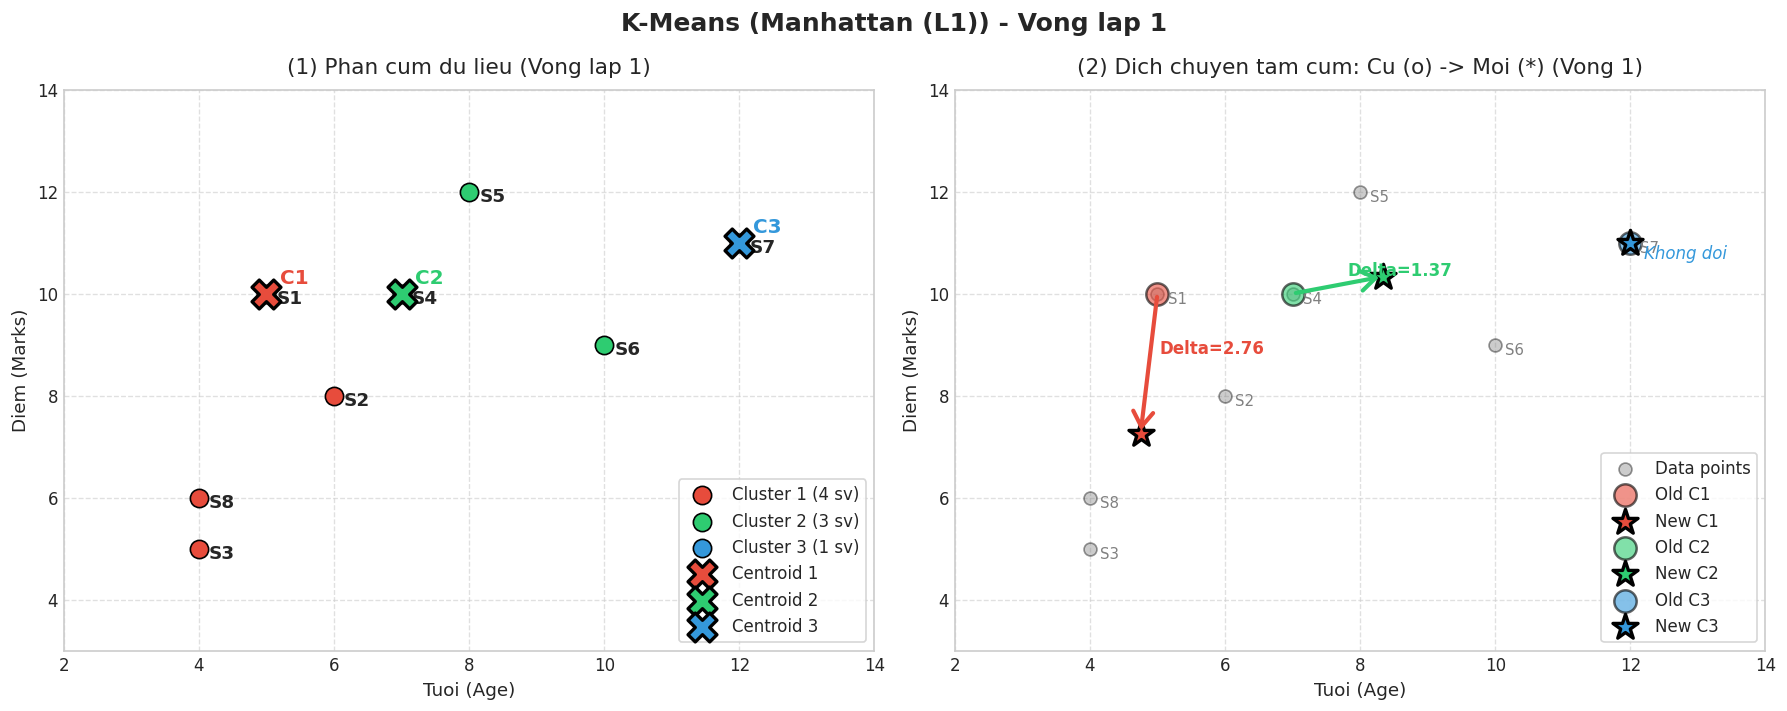


--- [Vong lap 2] ---
Sinh vien  Age (x)  Marks (y)  Dist C1  Dist C2  Dist C3   Gan cum
       S1      5.0       10.0      3.0 3.666667      8.0 Cluster 1
       S2      6.0        8.0      2.0 4.666667      9.0 Cluster 1
       S3      4.0        5.0      3.0 9.666667     14.0 Cluster 1
       S4      7.0       10.0      5.0 1.666667      6.0 Cluster 2
       S5      8.0       12.0      8.0 2.000000      5.0 Cluster 2
       S6     10.0        9.0      7.0 3.000000      4.0 Cluster 2
       S7     12.0       11.0     11.0 4.333333      0.0 Cluster 3
       S8      4.0        6.0      2.0 8.666667     13.0 Cluster 1


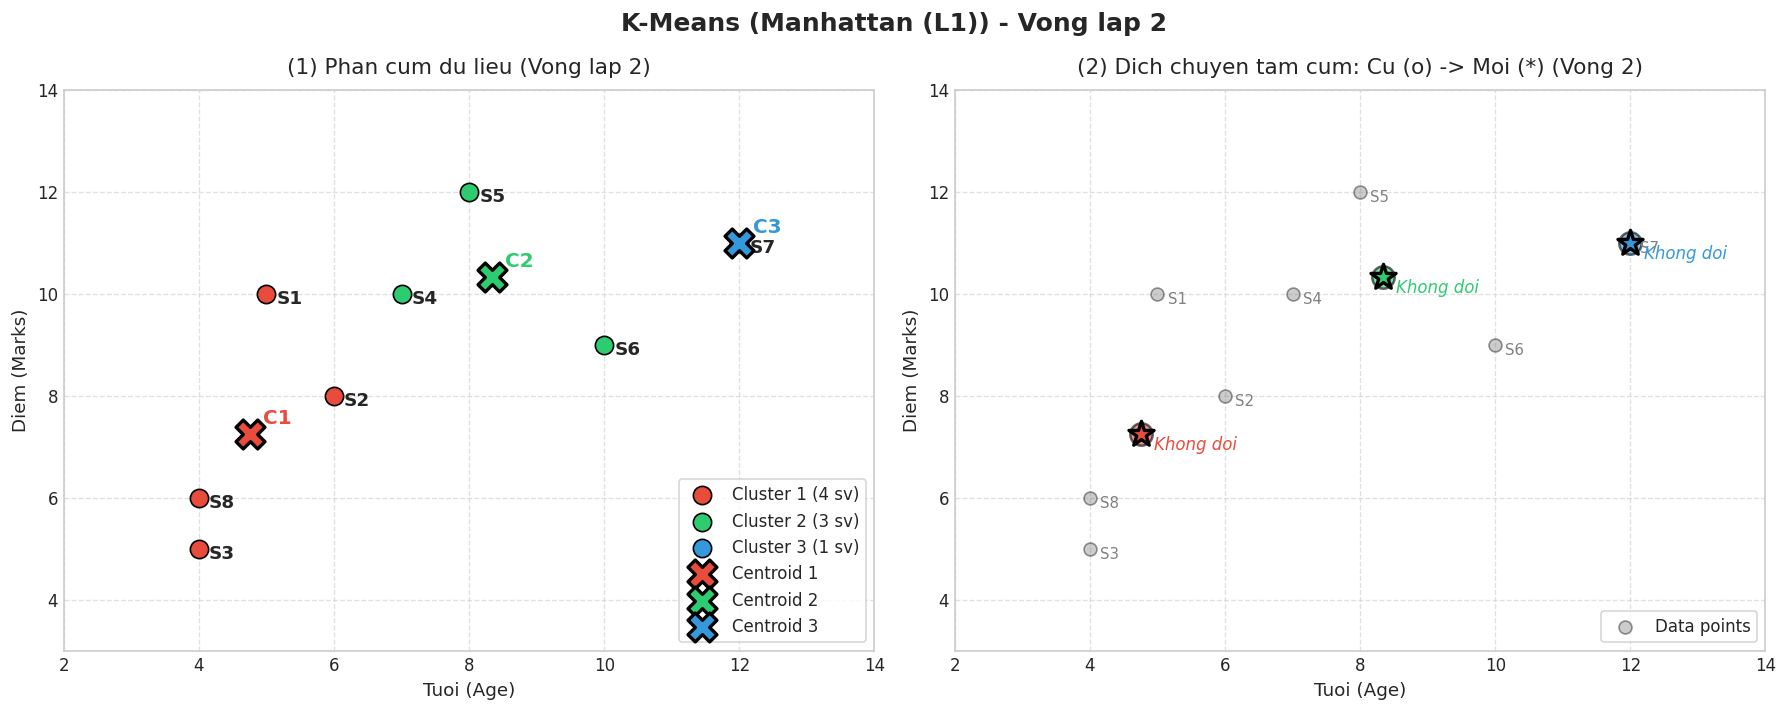

==> K-Means (Manhattan (L1)) DA HOI TU TAI VONG LAP 2!
      THUC THI K-MEANS - KHOANG CACH: EUCLIDEAN (L2)

--- [Vong lap 1] ---
Sinh vien  Age (x)  Marks (y)  Dist C1  Dist C2   Dist C3   Gan cum
       S1      5.0       10.0 0.000000 2.000000  7.071068 Cluster 1
       S2      6.0        8.0 2.236068 2.236068  6.708204 Cluster 1
       S3      4.0        5.0 5.099020 5.830952 10.000000 Cluster 1
       S4      7.0       10.0 2.000000 0.000000  5.099020 Cluster 2
       S5      8.0       12.0 3.605551 2.236068  4.123106 Cluster 2
       S6     10.0        9.0 5.099020 3.162278  2.828427 Cluster 3
       S7     12.0       11.0 7.071068 5.099020  0.000000 Cluster 3
       S8      4.0        6.0 4.123106 5.000000  9.433981 Cluster 1


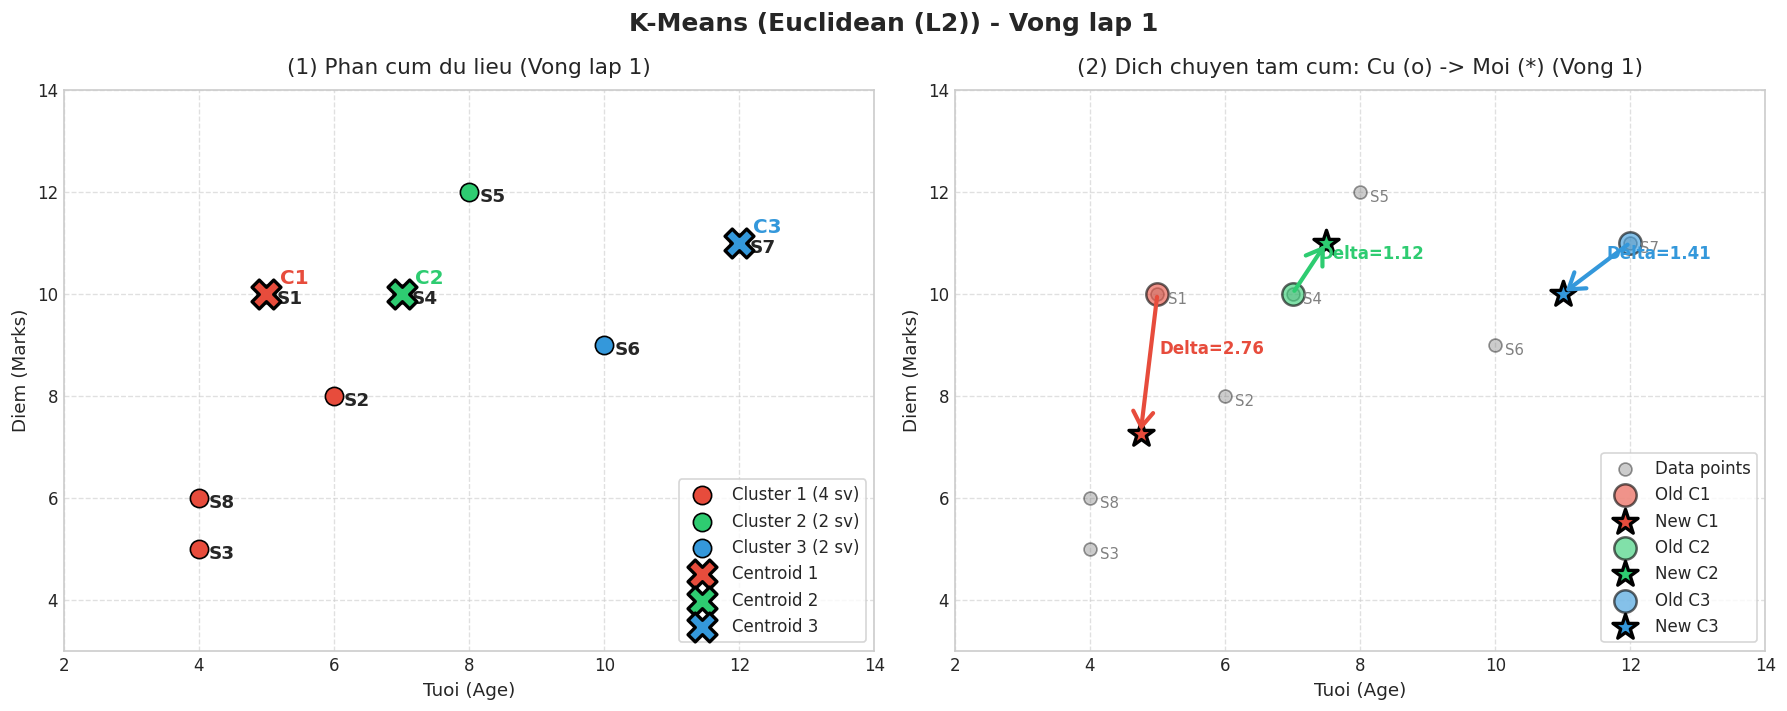


--- [Vong lap 2] ---
Sinh vien  Age (x)  Marks (y)  Dist C1  Dist C2  Dist C3   Gan cum
       S1      5.0       10.0 2.761340 2.692582 6.000000 Cluster 2
       S2      6.0        8.0 1.457738 3.354102 5.385165 Cluster 1
       S3      4.0        5.0 2.371708 6.946222 8.602325 Cluster 1
       S4      7.0       10.0 3.553168 1.118034 4.000000 Cluster 2
       S5      8.0       12.0 5.755432 1.118034 3.605551 Cluster 2
       S6     10.0        9.0 5.533986 3.201562 1.414214 Cluster 3
       S7     12.0       11.0 8.162414 4.500000 1.414214 Cluster 3
       S8      4.0        6.0 1.457738 6.103278 8.062258 Cluster 1


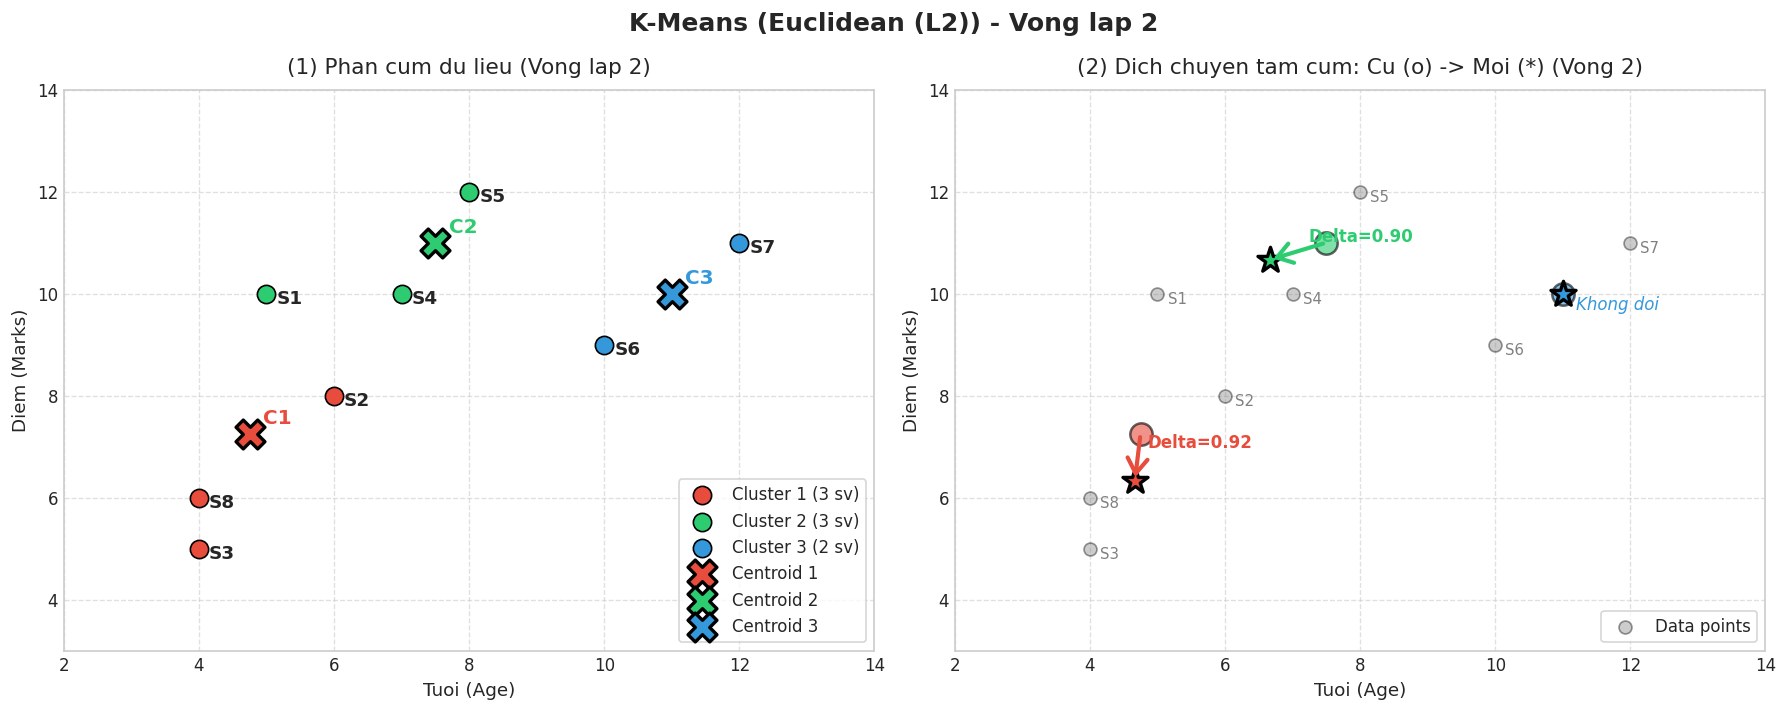


--- [Vong lap 3] ---
Sinh vien  Age (x)  Marks (y)  Dist C1  Dist C2  Dist C3   Gan cum
       S1      5.0       10.0 3.681787 1.795055 6.000000 Cluster 2
       S2      6.0        8.0 2.134375 2.748737 5.385165 Cluster 1
       S3      4.0        5.0 1.490712 6.262765 8.602325 Cluster 1
       S4      7.0       10.0 4.346135 0.745356 4.000000 Cluster 2
       S5      8.0       12.0 6.574361 1.885618 3.605551 Cluster 2
       S6     10.0        9.0 5.962848 3.726780 1.414214 Cluster 3
       S7     12.0       11.0 8.692270 5.343740 1.414214 Cluster 3
       S8      4.0        6.0 0.745356 5.374838 8.062258 Cluster 1


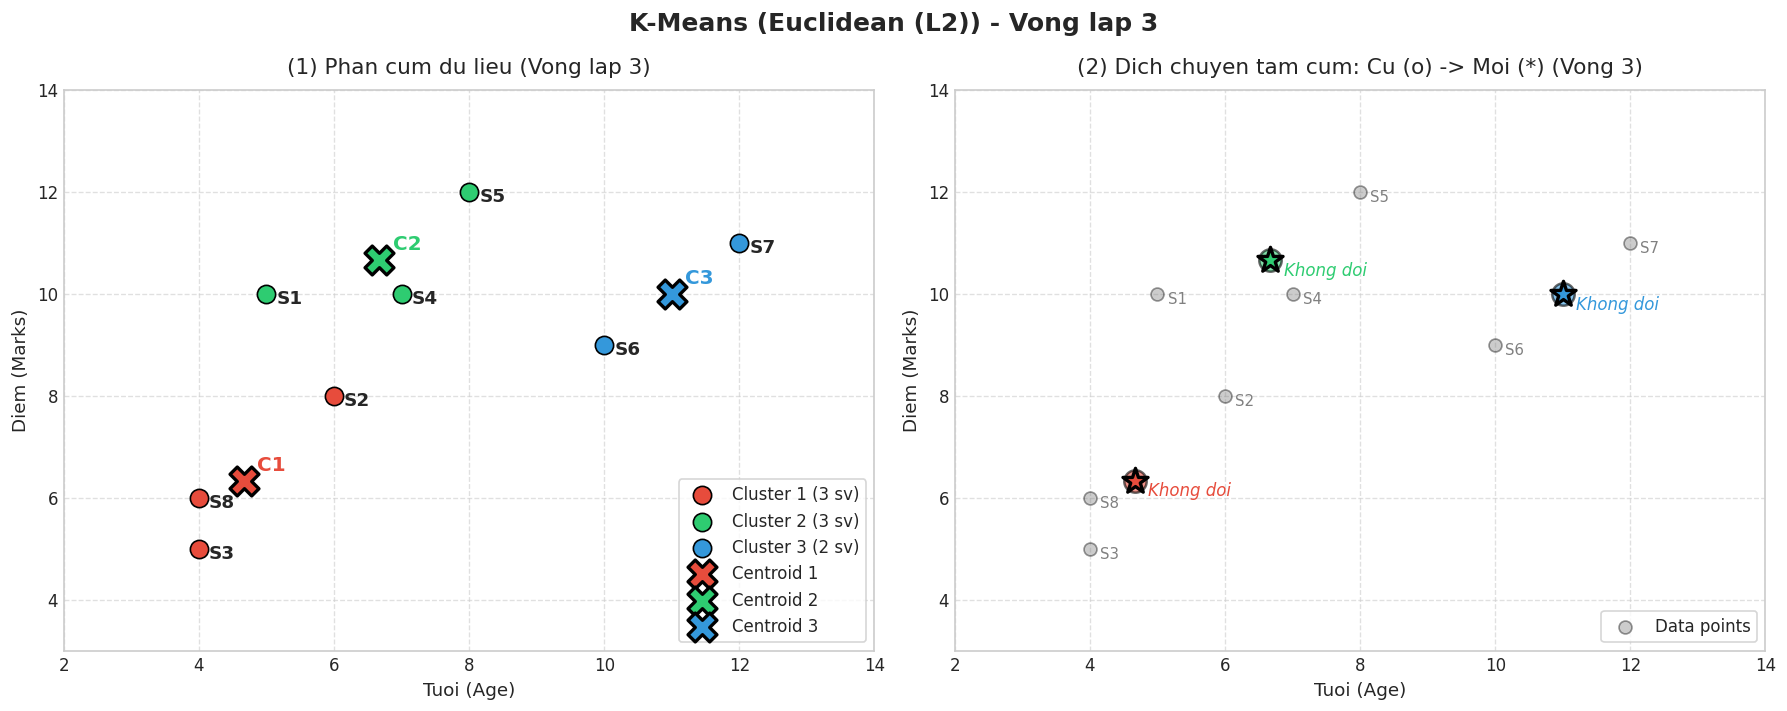

==> K-Means (Euclidean (L2)) DA HOI TU TAI VONG LAP 3!


In [2]:
def run_kmeans_with_visualization(data, student_names, initial_centers, metric='euclidean'):
    metric_name = "Manhattan (L1)" if metric == 'manhattan' else "Euclidean (L2)"
    print(f"===============================================================")
    print(f"      THUC THI K-MEANS - KHOANG CACH: {metric_name.upper()}")
    print(f"===============================================================")
    
    centroids = np.copy(initial_centers)
    history_centroids = [np.copy(centroids)]
    history_clusters = []
    
    colors = ['#E74C3C', '#2ECC71', '#3498DB'] # Do, Luc, Lam cho 3 cum
    cluster_names = ['Cluster 1', 'Cluster 2', 'Cluster 3']
    
    it = 1
    while True:
        # Buoc 1: Tinh khoang cach
        N, K = len(data), len(centroids)
        dists = np.zeros((N, K))
        for i in range(N):
            for k in range(K):
                if metric == 'manhattan':
                    dists[i, k] = np.sum(np.abs(data[i] - centroids[k]))
                else:
                    dists[i, k] = np.linalg.norm(data[i] - centroids[k])
                    
        # Gan cum (chon argmin dau tien neu hoa)
        clusters = np.argmin(dists, axis=1)
        history_clusters.append(clusters)
        
        # Buoc 2: Cap nhat tam cum
        new_centroids = np.zeros_like(centroids)
        for k in range(K):
            members = data[clusters == k]
            if len(members) > 0:
                new_centroids[k] = members.mean(axis=0)
            else:
                new_centroids[k] = centroids[k]
                
        # In ket qua vong lap
        print(f"\n--- [Vong lap {it}] ---")
        df_iter = pd.DataFrame({
            'Sinh vien': student_names,
            'Age (x)': data[:, 0],
            'Marks (y)': data[:, 1],
            'Dist C1': dists[:, 0],
            'Dist C2': dists[:, 1],
            'Dist C3': dists[:, 2],
            'Gan cum': [f'Cluster {c+1}' for c in clusters]
        })
        print(df_iter.to_string(index=False))
        
        # Ve 2 bieu do side-by-side
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))
        fig.suptitle(f"K-Means ({metric_name}) - Vong lap {it}", fontsize=15, fontweight='bold', y=0.98)
        
        # Do thi 1: Ket qua phan cum hien tai
        ax1 = axes[0]
        for k in range(K):
            members = data[clusters == k]
            if len(members) > 0:
                ax1.scatter(members[:, 0], members[:, 1], s=120, color=colors[k], label=f'{cluster_names[k]} ({len(members)} sv)', edgecolors='black', zorder=3)
        # Ve tam hien tai
        for k in range(K):
            ax1.scatter(centroids[k, 0], centroids[k, 1], s=300, color=colors[k], marker='X', edgecolors='black', linewidths=2, label=f'Centroid {k+1}', zorder=4)
            ax1.text(centroids[k, 0] + 0.2, centroids[k, 1] + 0.2, f'C{k+1}', fontsize=12, fontweight='bold', color=colors[k])
            
        # Ghi nhan ten sinh vien
        for i in range(N):
            ax1.text(data[i, 0] + 0.15, data[i, 1] - 0.2, student_names[i], fontsize=11, fontweight='bold')
            
        ax1.set_title(f"(1) Phan cum du lieu (Vong lap {it})", fontsize=13, pad=10)
        ax1.set_xlabel("Tuoi (Age)", fontsize=11)
        ax1.set_ylabel("Diem (Marks)", fontsize=11)
        ax1.set_xlim(2, 14)
        ax1.set_ylim(3, 14)
        ax1.legend(loc='lower right', frameon=True)
        ax1.grid(True, linestyle='--', alpha=0.6)
        
        # Do thi 2: Centroid Shift (Do dich chuyen tam)
        ax2 = axes[1]
        ax2.scatter(data[:, 0], data[:, 1], s=60, color='gray', alpha=0.4, edgecolors='black', label='Data points')
        for i in range(N):
            ax2.text(data[i, 0] + 0.15, data[i, 1] - 0.2, student_names[i], fontsize=9, color='gray')
            
        for k in range(K):
            ax2.scatter(centroids[k, 0], centroids[k, 1], s=180, color=colors[k], marker='o', edgecolors='black', linewidths=1.5, alpha=0.6, label=f'Old C{k+1}' if it==1 else "")
            ax2.scatter(new_centroids[k, 0], new_centroids[k, 1], s=250, color=colors[k], marker='*', edgecolors='black', linewidths=2, label=f'New C{k+1}' if it==1 else "")
            
            dx = new_centroids[k, 0] - centroids[k, 0]
            dy = new_centroids[k, 1] - centroids[k, 1]
            dist_shift = np.sqrt(dx**2 + dy**2)
            if dist_shift > 1e-4:
                ax2.annotate('', xy=(new_centroids[k, 0], new_centroids[k, 1]),
                             xytext=(centroids[k, 0], centroids[k, 1]),
                             arrowprops=dict(arrowstyle="->,head_width=0.4,head_length=0.6", color=colors[k], lw=2.5, mutation_scale=15))
                mid_x = (centroids[k, 0] + new_centroids[k, 0]) / 2
                mid_y = (centroids[k, 1] + new_centroids[k, 1]) / 2
                ax2.text(mid_x + 0.15, mid_y + 0.2, f'Delta={dist_shift:.2f}', fontsize=10, color=colors[k], fontweight='bold')
            else:
                ax2.text(centroids[k, 0] + 0.2, centroids[k, 1] - 0.3, "Khong doi", fontsize=10, color=colors[k], fontstyle='italic')
                
        ax2.set_title(f"(2) Dich chuyen tam cum: Cu (o) -> Moi (*) (Vong {it})", fontsize=13, pad=10)
        ax2.set_xlabel("Tuoi (Age)", fontsize=11)
        ax2.set_ylabel("Diem (Marks)", fontsize=11)
        ax2.set_xlim(2, 14)
        ax2.set_ylim(3, 14)
        ax2.legend(loc='lower right', frameon=True)
        ax2.grid(True, linestyle='--', alpha=0.6)
        
        plt.tight_layout()
        plt.show()
        
        # Kiem tra dieu kien hoi tu
        if np.allclose(centroids, new_centroids, atol=1e-4):
            print(f"==> K-Means ({metric_name}) DA HOI TU TAI VONG LAP {it}!")
            break
            
        centroids = np.copy(new_centroids)
        history_centroids.append(np.copy(centroids))
        it += 1

# Chay K-Means Manhattan
run_kmeans_with_visualization(data, student_names, initial_centroids, metric='manhattan')

# Chay K-Means Euclidean
run_kmeans_with_visualization(data, student_names, initial_centroids, metric='euclidean')


---
# BÀI 2: THUẬT TOÁN FUZZY C-MEANS (FCM) (EXERCISE 02)

### Cơ sở lý thuyết & Công thức toán học FCM

Trong thuật toán Fuzzy C-Means (FCM), mỗi điểm dữ liệu không thuộc hoàn toàn 100% vào một cụm duy nhất như K-Means mà có một **độ thuộc mờ (Fuzzy Membership degree)** $u_{ij} \in [0, 1]$ đối với cụm $i$.
Ràng buộc bảo toàn: Với mỗi điểm $x_j$, tổng độ thuộc trên tất cả các cụm bằng 1:
$$\sum_{i=1}^C u_{ij} = 1, \quad \forall j = 1, \dots, N$$

**1. Hàm mục tiêu mờ:**
$$J_m(U, C) = \sum_{j=1}^N \sum_{i=1}^C (u_{ij})^m \cdot d^2(x_j, c_i)$$
- $C = 3$: Số cụm mờ.
- $N = 8$: Số điểm dữ liệu.
- $m = 2$: Hệ số làm mờ (fuzzification parameter).
- $d(x_j, c_i)$: Khoảng cách Euclidean từ điểm $x_j$ đến tâm cụm $c_i$:
  $$d(x_j, c_i) = \|x_j - c_i\| = \sqrt{(x_{j, 1} - c_{i, 1})^2 + (x_{j, 2} - c_{i, 2})^2}$$

**2. Công thức tính ma trận độ thuộc $u_{ij}$:**
$$u_{ij} = \frac{1}{\sum_{k=1}^C \left(\frac{d(x_j, c_i)}{d(x_j, c_k)}\right)^{\frac{2}{m-1}}}$$
Khi $m = 2$, số mũ $\frac{2}{m-1} = \frac{2}{2-1} = 2$. Do đó công thức rút gọn thành:
$$u_{ij} = \frac{\frac{1}{d^2(x_j, c_i)}}{\sum_{k=1}^C \frac{1}{d^2(x_j, c_k)}}$$

*Trường hợp đặc biệt:* Nếu $x_j$ trùng với tâm $c_i$ ($d(x_j, c_i) = 0$):
$$u_{ij} = 1 \quad \text{và} \quad u_{kj} = 0 \quad (\forall k \neq i)$$

**3. Công thức cập nhật tâm cụm $c_i$:**
$$c_i = \frac{\sum_{j=1}^N (u_{ij})^m \cdot x_j}{\sum_{j=1}^N (u_{ij})^m} = \frac{\sum_{j=1}^N (u_{ij})^2 \cdot x_j}{\sum_{j=1}^N (u_{ij})^2}$$


## 2.a. Thực hiện thuật toán FCM từng bước cho 3 vòng lặp đầu tiên

> **Yêu cầu bổ sung của giảng viên đối với câu 2.a:** Chọn 1 trong 8 mẫu dữ liệu ($S_1, S_2, \dots, S_8$) để xét và trình bày chi tiết từng bước tính toán (tính tay có công thức đầy đủ từ khoảng cách đến vector độ thuộc mờ $\mu$), sau đó áp dụng quy trình để lập 2 bảng tiêu chuẩn cho các vòng lặp.

---

### TÍNH TAY CHI TIẾT 1 MẪU ĐƯỢC CHỌN (MẪU $S_2(6, 8)$ - VÒNG LẶP 1)

**Lý do chọn mẫu $S_2(6, 8)$:**
- Trong 8 sinh viên, các điểm $S_1, S_4, S_7$ trùng trực tiếp với các tâm ban đầu nên có khoảng cách bằng 0.
- Điểm $S_2(6, 8)$ là mẫu tổng quát và đặc trưng nhất: khoảng cách tới cả 3 tâm đều lớn hơn 0, đồng thời $S_2$ nằm ở vị trí giáp ranh đối xứng giữa Cụm 1 và Cụm 2 ($d(S_2, C_1) = d(S_2, C_2) = \sqrt{5}$), phản ánh trực quan và chuẩn xác nhất bản chất phân cụm mờ.

Các tâm cụm ban đầu:
$$C_1 = (5, 10), \quad C_2 = (7, 10), \quad C_3 = (12, 11)$$

#### Bước 1: Tính khoảng cách Euclidean từ $S_2(6, 8)$ đến từng tâm cụm
- **Khoảng cách đến $C_1(5, 10)$:**
  $$d(S_2, C_1) = \sqrt{(6 - 5)^2 + (8 - 10)^2} = \sqrt{1^2 + (-2)^2} = \sqrt{1 + 4} = \sqrt{5} \approx 2.2361$$
  $$\implies d^2(S_2, C_1) = 5$$

- **Khoảng cách đến $C_2(7, 10)$:**
  $$d(S_2, C_2) = \sqrt{(6 - 7)^2 + (8 - 10)^2} = \sqrt{(-1)^2 + (-2)^2} = \sqrt{1 + 4} = \sqrt{5} \approx 2.2361$$
  $$\implies d^2(S_2, C_2) = 5$$

- **Khoảng cách đến $C_3(12, 11)$:**
  $$d(S_2, C_3) = \sqrt{(6 - 12)^2 + (8 - 11)^2} = \sqrt{(-6)^2 + (-3)^2} = \sqrt{36 + 9} = \sqrt{45} \approx 6.7082$$
  $$\implies d^2(S_2, C_3) = 45$$

#### Bước 2: Tính nghịch đảo bình phương khoảng cách và tổng mẫu số
$$\frac{1}{d^2(S_2, C_1)} = \frac{1}{5} = 0.2000$$
$$\frac{1}{d^2(S_2, C_2)} = \frac{1}{5} = 0.2000$$
$$\frac{1}{d^2(S_2, C_3)} = \frac{1}{45} \approx 0.02222$$

Tổng mẫu số:
$$\sum_{k=1}^3 \frac{1}{d^2(S_2, C_k)} = \frac{1}{5} + \frac{1}{5} + \frac{1}{45} = \frac{9}{45} + \frac{9}{45} + \frac{1}{45} = \frac{19}{45} \approx 0.42222$$

#### Bước 3: Tính các độ thuộc mờ $\mu_1, \mu_2, \mu_3$
- **Độ thuộc Cụm 1 ($u_{1, 2}$):**
  $$u_{1, 2} = \frac{\frac{1}{d^2(S_2, C_1)}}{\sum_{k=1}^3 \frac{1}{d^2(S_2, C_k)}} = \frac{\frac{1}{5}}{\frac{19}{45}} = \frac{1}{5} \times \frac{45}{19} = \frac{9}{19} \approx \mathbf{0.4737} \quad (47.37\%)$$

- **Độ thuộc Cụm 2 ($u_{2, 2}$):**
  $$u_{2, 2} = \frac{\frac{1}{d^2(S_2, C_2)}}{\sum_{k=1}^3 \frac{1}{d^2(S_2, C_k)}} = \frac{\frac{1}{5}}{\frac{19}{45}} = \frac{1}{5} \times \frac{45}{19} = \frac{9}{19} \approx \mathbf{0.4737} \quad (47.37\%)$$

- **Độ thuộc Cụm 3 ($u_{3, 2}$):**
  $$u_{3, 2} = \frac{\frac{1}{d^2(S_2, C_3)}}{\sum_{k=1}^3 \frac{1}{d^2(S_2, C_k)}} = \frac{\frac{1}{45}}{\frac{19}{45}} = \frac{1}{45} \times \frac{45}{19} = \frac{1}{19} \approx \mathbf{0.0526} \quad (5.26\%)$$

- **Kiểm tra điều kiện chuẩn hóa:**
  $$\sum_{i=1}^3 u_{i, 2} = \frac{9}{19} + \frac{9}{19} + \frac{1}{19} = \frac{19}{19} = \mathbf{1.0000} \quad \text{(Thỏa mãn tuyệt đối)}$$

---

#### Bước 4: Xử lý các điểm trùng tâm (Khoảng cách = 0)
- $S_1(5, 10) \equiv C_1(5, 10) \implies d(S_1, C_1) = 0 \implies u_{11} = 1.0, \; u_{21} = 0.0, \; u_{31} = 0.0$
- $S_4(7, 10) \equiv C_2(7, 10) \implies d(S_4, C_2) = 0 \implies u_{14} = 0.0, \; u_{24} = 1.0, \; u_{34} = 0.0$
- $S_7(12, 11) \equiv C_3(12, 11) \implies d(S_7, C_3) = 0 \implies u_{17} = 0.0, \; u_{27} = 0.0, \; u_{37} = 1.0$

---

#### Bước 5: Tính tay mẫu cập nhật tọa độ tâm cụm $C_1$ (Centroid Update)
Công thức cập nhật:
$$C_1 = \frac{\sum_{j=1}^8 (u_{1j})^2 \cdot (x_j, y_j)}{\sum_{j=1}^8 (u_{1j})^2}$$

Bảng trọng số bình phương $(u_{1j})^2$:
- $S_1(5, 10): (1.0000)^2 = 1.0000$
- $S_2(6, 8): (0.4737)^2 = 0.2244$
- $S_3(4, 5): (0.4939)^2 = 0.2439$
- $S_4(7, 10): (0.0000)^2 = 0.0000$
- $S_5(8, 12): (0.2291)^2 = 0.0525$
- $S_6(10, 9): (0.1460)^2 = 0.0213$
- $S_7(12, 11): (0.0000)^2 = 0.0000$
- $S_8(4, 6): (0.5345)^2 = 0.2857$

**Tổng mẫu số (Tổng trọng số):**
$$\sum_{j=1}^8 (u_{1j})^2 = 1.0000 + 0.2244 + 0.2439 + 0 + 0.0525 + 0.0213 + 0 + 0.2857 = \mathbf{1.8278}$$

**Tọa độ $x$ mới của $C_1$:**
$$c_{1, x} = \frac{1.0(5) + 0.2244(6) + 0.2439(4) + 0(7) + 0.0525(8) + 0.0213(10) + 0(12) + 0.2857(4)}{1.8278} = \frac{9.0980}{1.8278} \approx \mathbf{4.9775}$$

**Tọa độ $y$ mới của $C_1$:**
$$c_{1, y} = \frac{1.0(10) + 0.2244(8) + 0.2439(5) + 0(10) + 0.0525(12) + 0.0213(9) + 0(11) + 0.2857(6)}{1.8278} = \frac{15.5507}{1.8278} \approx \mathbf{8.5078}$$

$$\implies C_1^{(updated)} = (4.9775, 8.5078)$$


In [3]:
# Ham ho tro kiem tra cac buoc tinh tay chi tiet cho bat ky mau nao trong 8 mau sinh vien
def print_manual_calculation(sample_idx=1, centers=initial_centroids):
    name = student_names[sample_idx]
    pt = data[sample_idx]
    print(f"=== CHI TIET CAC BUOC TINH TAY CHO MAU {name}({pt[0]:.0f}, {pt[1]:.0f}) ===")
    
    dists = [np.linalg.norm(pt - c) for c in centers]
    for k in range(3):
        print(f"- Khoang cach toi C{k+1}{tuple(np.round(centers[k], 4))}: d{k+1} = {dists[k]:.4f} => d{k+1}^2 = {dists[k]**2:.4f}")
        
    zero_idx = [k for k, d in enumerate(dists) if d < 1e-6]
    if zero_idx:
        u = [1.0 if k == zero_idx[0] else 0.0 for k in range(3)]
        print(f"=> Mau trung voi tam C{zero_idx[0]+1}, do thuoc u = {u}")
    else:
        inv_sq = [1.0 / (d**2) for d in dists]
        sum_inv = sum(inv_sq)
        u = [val / sum_inv for val in inv_sq]
        print(f"- Nghich dao binh phuong khoang cach: {[round(v, 4) for v in inv_sq]}")
        print(f"- Tong mau so: {sum_inv:.4f}")
        print(f"- Vector do thuoc mo: μ1 = {u[0]:.4f} ({u[0]*100:.2f}%), μ2 = {u[1]:.4f} ({u[1]*100:.2f}%), μ3 = {u[2]:.4f} ({u[2]*100:.2f}%)")
        print(f"- Tong cac do thuoc: {sum(u):.4f} (Chuan hoa)")

# Minh hoa goi ham cho mau S2 da chon
print_manual_calculation(sample_idx=1)


=== CHI TIET CAC BUOC TINH TAY CHO MAU S2(6, 8) ===
- Khoang cach toi C1(np.float64(5.0), np.float64(10.0)): d1 = 2.2361 => d1^2 = 5.0000
- Khoang cach toi C2(np.float64(7.0), np.float64(10.0)): d2 = 2.2361 => d2^2 = 5.0000
- Khoang cach toi C3(np.float64(12.0), np.float64(11.0)): d3 = 6.7082 => d3^2 = 45.0000
- Nghich dao binh phuong khoang cach: [np.float64(0.2), np.float64(0.2), np.float64(0.0222)]
- Tong mau so: 0.4222
- Vector do thuoc mo: μ1 = 0.4737 (47.37%), μ2 = 0.4737 (47.37%), μ3 = 0.0526 (5.26%)
- Tong cac do thuoc: 1.0000 (Chuan hoa)


### KẺ 2 BẢNG TIÊU CHUẨN CHO 3 VÒNG LẶP ĐẦU TIÊN

Dưới đây là 2 bảng tiêu chuẩn cho từng vòng lặp theo đúng quy định trong đề bài:
1. **Distance & Membership Computation Table**
2. **Cluster Centroid Update Table**

---

### VÒNG LẶP 1 (ITERATION 1)
Tâm cụm: $C_1(5, 10), C_2(7, 10), C_3(12, 11)$

#### Bảng 1: Distance & Membership Computation (Iteration 1)
| No | Age | Marks | Dist to C1 | Dist to C2 | Dist to C3 | $\mu_1$ (Cluster 1) | $\mu_2$ (Cluster 2) | $\mu_3$ (Cluster 3) | $\sum \mu$ |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| $S_1$ | 5 | 10 | 0.0000 | 2.0000 | 7.0711 | **1.0000** | 0.0000 | 0.0000 | 1.0000 |
| $S_2$ | 6 | 8 | 2.2361 | 2.2361 | 6.7082 | **0.4737** | **0.4737** | 0.0526 | 1.0000 |
| $S_3$ | 4 | 5 | 5.0990 | 5.8310 | 10.0000 | **0.4939** | 0.3777 | 0.1284 | 1.0000 |
| $S_4$ | 7 | 10 | 2.0000 | 0.0000 | 5.0990 | 0.0000 | **1.0000** | 0.0000 | 1.0000 |
| $S_5$ | 8 | 12 | 3.6056 | 2.2361 | 4.1231 | 0.2291 | **0.5957** | 0.1752 | 1.0000 |
| $S_6$ | 10 | 9 | 5.0990 | 3.1623 | 2.8284 | 0.1460 | 0.3796 | **0.4745** | 1.0000 |
| $S_7$ | 12 | 11 | 7.0711 | 5.0990 | 0.0000 | 0.0000 | 0.0000 | **1.0000** | 1.0000 |
| $S_8$ | 4 | 6 | 4.1231 | 5.0000 | 9.4340 | **0.5345** | 0.3634 | 0.1021 | 1.0000 |

#### Bảng 2: Cluster Centroid Update (Iteration 1)
| Centroid | Old Coordinates | Updated Coordinates |
|:---:|:---:|:---:|
| **$C_1$** | (5.0000, 10.0000) | **(4.9775, 8.5078)** |
| **$C_2$** | (7.0000, 10.0000) | **(6.8691, 9.4371)** |
| **$C_3$** | (12.0000, 11.0000) | **(11.3738, 10.5497)** |

---

### VÒNG LẶP 2 (ITERATION 2)
Tâm cụm: $C_1(4.9775, 8.5078), C_2(6.8691, 9.4371), C_3(11.3738, 10.5497)$

#### Bảng 1: Distance & Membership Computation (Iteration 2)
| No | Age | Marks | Dist to C1 | Dist to C2 | Dist to C3 | $\mu_1$ (Cluster 1) | $\mu_2$ (Cluster 2) | $\mu_3$ (Cluster 3) | $\sum \mu$ |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| $S_1$ | 5 | 10 | 1.4924 | 1.9520 | 6.3975 | **0.6102** | 0.3566 | 0.0332 | 1.0000 |
| $S_2$ | 6 | 8 | 1.1417 | 1.6794 | 5.9480 | **0.6671** | 0.3083 | 0.0246 | 1.0000 |
| $S_3$ | 4 | 5 | 3.6414 | 5.2839 | 9.2289 | **0.6133** | 0.2913 | 0.0955 | 1.0000 |
| $S_4$ | 7 | 10 | 2.5134 | 0.5779 | 4.4082 | 0.0494 | **0.9345** | 0.0161 | 1.0000 |
| $S_5$ | 8 | 12 | 4.6186 | 2.8013 | 3.6724 | 0.1887 | **0.5129** | 0.2984 | 1.0000 |
| $S_6$ | 10 | 9 | 5.0466 | 3.1613 | 2.0710 | 0.1054 | 0.2686 | **0.6259** | 1.0000 |
| $S_7$ | 12 | 11 | 7.4516 | 5.3637 | 0.7713 | 0.0104 | 0.0200 | **0.9696** | 1.0000 |
| $S_8$ | 4 | 6 | 2.6916 | 4.4772 | 8.6645 | **0.6859** | 0.2479 | 0.0662 | 1.0000 |

#### Bảng 2: Cluster Centroid Update (Iteration 2)
| Centroid | Old Coordinates | Updated Coordinates |
|:---:|:---:|:---:|
| **$C_1$** | (4.9775, 8.5078) | **(4.8637, 7.3195)** |
| **$C_2$** | (6.8691, 9.4371) | **(6.8056, 9.7428)** |
| **$C_3$** | (11.3738, 10.5497) | **(11.1225, 10.4609)** |

---

### VÒNG LẶP 3 (ITERATION 3)
Tâm cụm: $C_1(4.8637, 7.3195), C_2(6.8056, 9.7428), C_3(11.1225, 10.4609)$

#### Bảng 1: Distance & Membership Computation (Iteration 3)
| No | Age | Marks | Dist to C1 | Dist to C2 | Dist to C3 | $\mu_1$ (Cluster 1) | $\mu_2$ (Cluster 2) | $\mu_3$ (Cluster 3) | $\sum \mu$ |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| $S_1$ | 5 | 10 | 2.6840 | 1.8238 | 6.1398 | 0.2979 | **0.6452** | 0.0569 | 1.0000 |
| $S_2$ | 6 | 8 | 1.3245 | 1.9200 | 5.6829 | **0.6535** | 0.3110 | 0.0355 | 1.0000 |
| $S_3$ | 4 | 5 | 2.4750 | 5.5105 | 8.9750 | **0.7826** | 0.1579 | 0.0595 | 1.0000 |
| $S_4$ | 7 | 10 | 3.4277 | 0.3224 | 4.1482 | 0.0087 | **0.9853** | 0.0060 | 1.0000 |
| $S_5$ | 8 | 12 | 5.6342 | 2.5538 | 3.4812 | 0.1178 | **0.5735** | 0.3086 | 1.0000 |
| $S_6$ | 10 | 9 | 5.4042 | 3.2797 | 1.8423 | 0.0812 | 0.2204 | **0.6984** | 1.0000 |
| $S_7$ | 12 | 11 | 8.0295 | 5.3444 | 1.0299 | 0.0156 | 0.0352 | **0.9491** | 1.0000 |
| $S_8$ | 4 | 6 | 1.5770 | 4.6776 | 8.4041 | **0.8704** | 0.0989 | 0.0306 | 1.0000 |

#### Bảng 2: Cluster Centroid Update (Iteration 3)
| Centroid | Old Coordinates | Updated Coordinates |
|:---:|:---:|:---:|
| **$C_1$** | (4.8637, 7.3195) | **(4.5455, 6.3678)** |
| **$C_2$** | (6.8056, 9.7428) | **(6.7088, 10.1335)** |
| **$C_3$** | (11.1225, 10.4609) | **(11.0469, 10.3882)** |


## 2.b. Cài đặt thuật toán Fuzzy C-Means (FCM) & Trực quan hóa

Cài đặt thuật toán FCM theo tiêu chuẩn đề bài:
- Số cụm: $C = 3$, tham số làm mờ: $m = 2$.
- Ngưỡng hội tụ: $\epsilon = 10^{-1} = 0.1$ (dừng khi $\max_i \|c_i^{(k)} - c_i^{(k-1)}\| < \epsilon$), hoặc tối đa 20 vòng lặp.
- Với mỗi vòng lặp, hiển thị **2 biểu đồ side-by-side**:
  1. **Soft Cluster Memberships:** Điểm dữ liệu được tô màu liên tục mờ bằng hệ màu RGB kết hợp 3 độ thuộc $(R=u_{1j}, G=u_{2j}, B=u_{3j})$. Điểm nào thuộc Cụm 1 sẽ ánh Đỏ, Cụm 2 ánh Lục, Cụm 3 ánh Lam; các điểm ở biên sẽ có màu hòa trộn phản ánh chính xác bản chất mờ.
  2. **Centroid Shift:** Minh họa vectơ dịch chuyển của 3 tâm cụm từ vị trí cũ sang vị trí mới.


       THUC THI FUZZY C-MEANS (FCM) - C=3, m=2, eps=0.1

--- [FCM Vong lap 1] --- (Do dich chuyen tam lon nhat = 1.4924)
Sinh vien     Age   Marks  Dist C1  Dist C2  Dist C3  μ1 (C1)  μ2 (C2)  μ3 (C3)    Σ μ
       S1  5.0000 10.0000   0.0000   2.0000   7.0711   1.0000   0.0000   0.0000 1.0000
       S2  6.0000  8.0000   2.2361   2.2361   6.7082   0.4737   0.4737   0.0526 1.0000
       S3  4.0000  5.0000   5.0990   5.8310  10.0000   0.4939   0.3777   0.1284 1.0000
       S4  7.0000 10.0000   2.0000   0.0000   5.0990   0.0000   1.0000   0.0000 1.0000
       S5  8.0000 12.0000   3.6056   2.2361   4.1231   0.2291   0.5957   0.1752 1.0000
       S6 10.0000  9.0000   5.0990   3.1623   2.8284   0.1460   0.3796   0.4745 1.0000
       S7 12.0000 11.0000   7.0711   5.0990   0.0000   0.0000   0.0000   1.0000 1.0000
       S8  4.0000  6.0000   4.1231   5.0000   9.4340   0.5345   0.3634   0.1021 1.0000
Tam cum          Toa do cu         Toa do moi Do dich chuyen
     C1  (5.0000, 10.0000)   (4.977

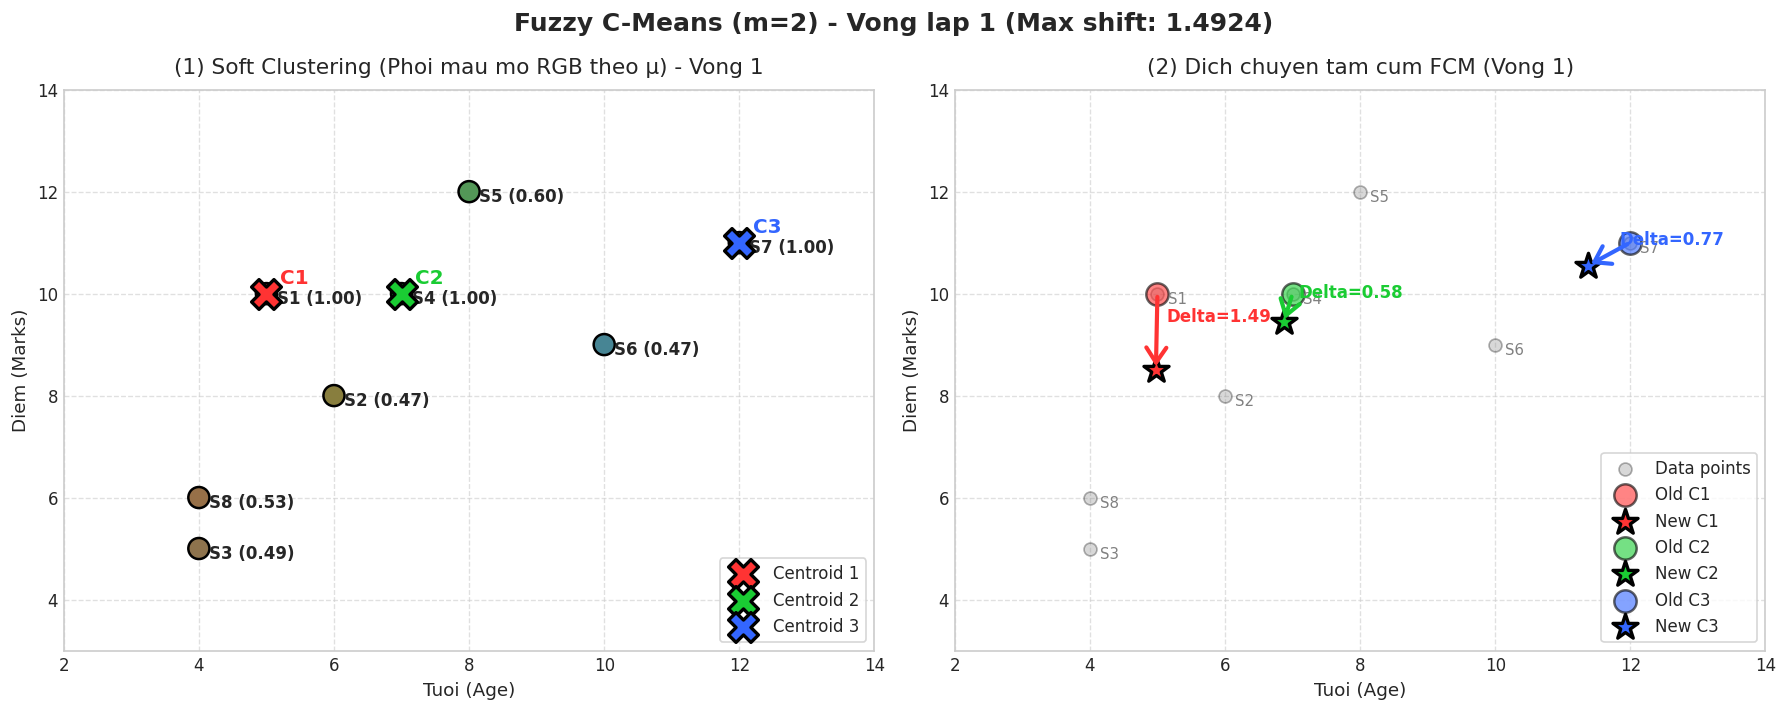


--- [FCM Vong lap 2] --- (Do dich chuyen tam lon nhat = 1.1938)
Sinh vien     Age   Marks  Dist C1  Dist C2  Dist C3  μ1 (C1)  μ2 (C2)  μ3 (C3)    Σ μ
       S1  5.0000 10.0000   1.4924   1.9520   6.3975   0.6102   0.3566   0.0332 1.0000
       S2  6.0000  8.0000   1.1417   1.6794   5.9480   0.6671   0.3083   0.0246 1.0000
       S3  4.0000  5.0000   3.6414   5.2839   9.2289   0.6133   0.2913   0.0955 1.0000
       S4  7.0000 10.0000   2.5134   0.5779   4.4082   0.0494   0.9345   0.0161 1.0000
       S5  8.0000 12.0000   4.6186   2.8013   3.6724   0.1887   0.5129   0.2984 1.0000
       S6 10.0000  9.0000   5.0466   3.1613   2.0710   0.1054   0.2686   0.6259 1.0000
       S7 12.0000 11.0000   7.4516   5.3637   0.7713   0.0104   0.0200   0.9696 1.0000
       S8  4.0000  6.0000   2.6916   4.4772   8.6645   0.6859   0.2479   0.0662 1.0000
Tam cum          Toa do cu         Toa do moi Do dich chuyen
     C1   (4.9775, 8.5078)   (4.8637, 7.3195)         1.1938
     C2   (6.8691, 9.4371)   (

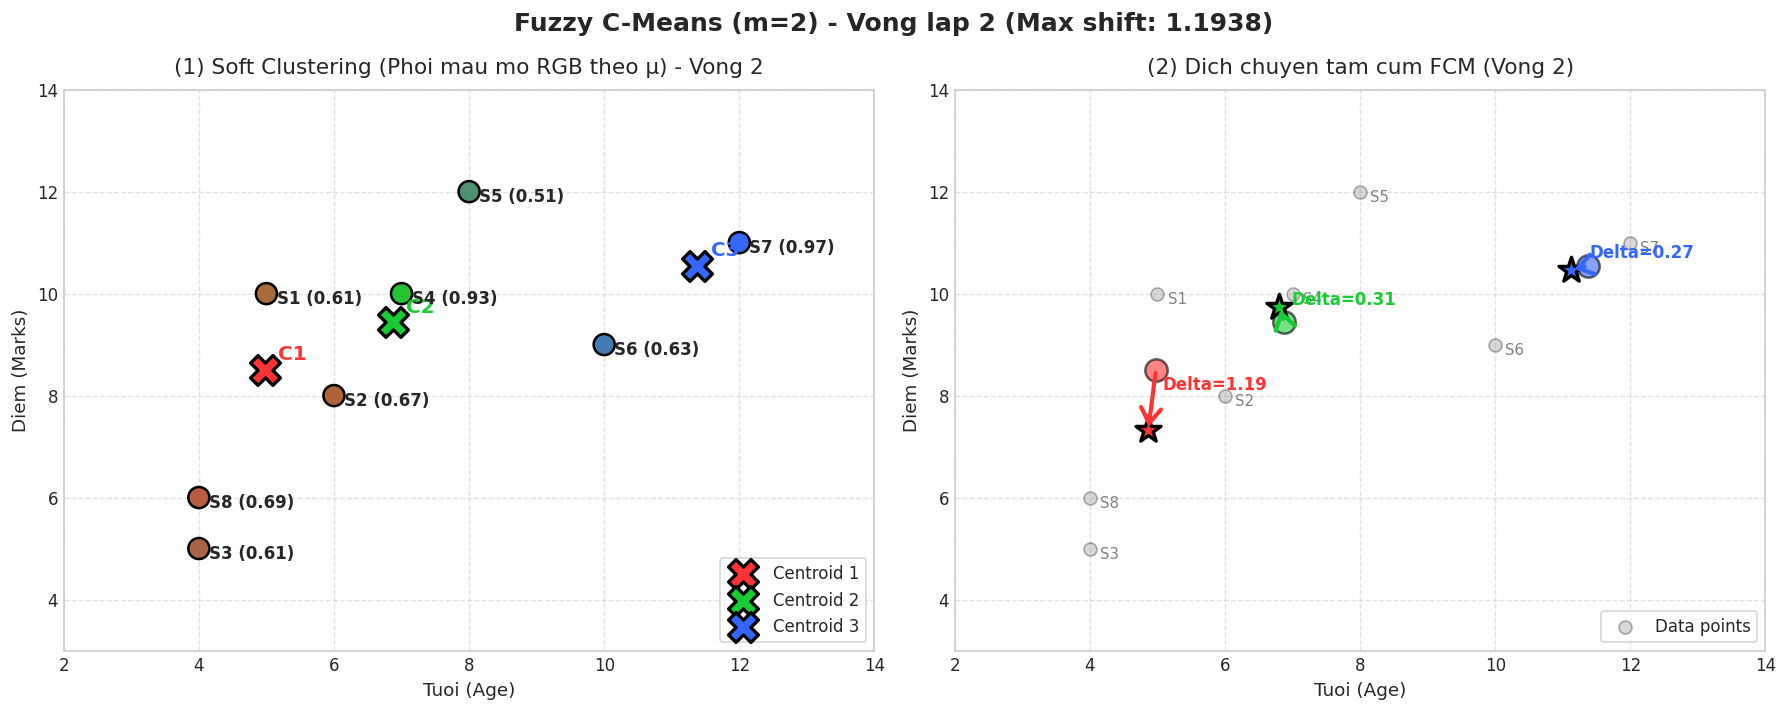


--- [FCM Vong lap 3] --- (Do dich chuyen tam lon nhat = 1.0035)
Sinh vien     Age   Marks  Dist C1  Dist C2  Dist C3  μ1 (C1)  μ2 (C2)  μ3 (C3)    Σ μ
       S1  5.0000 10.0000   2.6840   1.8238   6.1398   0.2979   0.6452   0.0569 1.0000
       S2  6.0000  8.0000   1.3245   1.9200   5.6829   0.6535   0.3110   0.0355 1.0000
       S3  4.0000  5.0000   2.4750   5.5105   8.9750   0.7826   0.1579   0.0595 1.0000
       S4  7.0000 10.0000   3.4277   0.3224   4.1482   0.0087   0.9853   0.0060 1.0000
       S5  8.0000 12.0000   5.6342   2.5538   3.4812   0.1178   0.5735   0.3086 1.0000
       S6 10.0000  9.0000   5.4042   3.2797   1.8423   0.0812   0.2204   0.6984 1.0000
       S7 12.0000 11.0000   8.0295   5.3444   1.0299   0.0156   0.0352   0.9491 1.0000
       S8  4.0000  6.0000   1.5770   4.6776   8.4041   0.8704   0.0989   0.0306 1.0000
Tam cum          Toa do cu         Toa do moi Do dich chuyen
     C1   (4.8637, 7.3195)   (4.5455, 6.3678)         1.0035
     C2   (6.8056, 9.7428)  (6

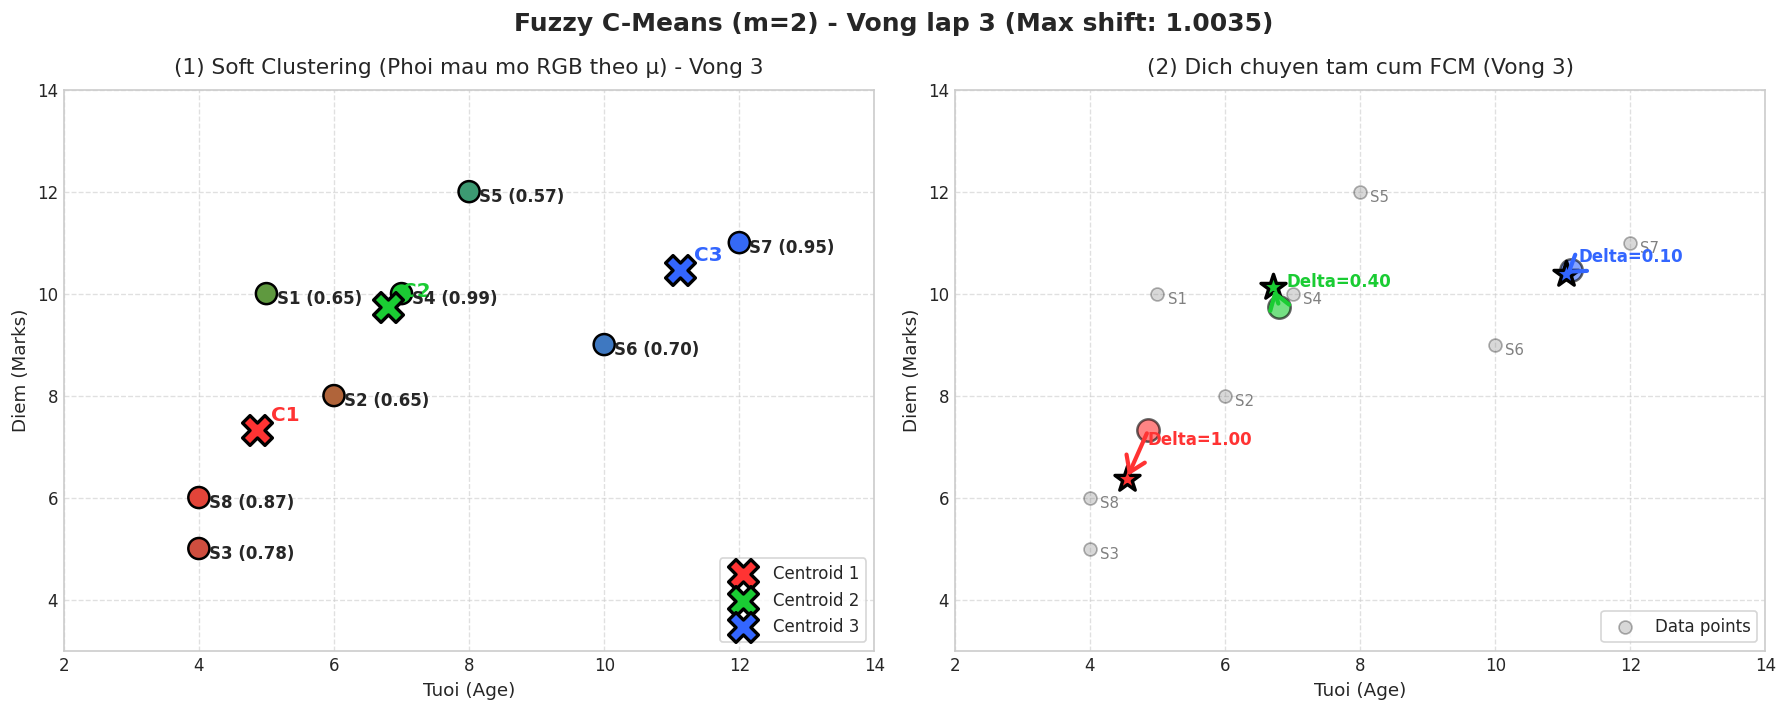


--- [FCM Vong lap 4] --- (Do dich chuyen tam lon nhat = 0.5564)
Sinh vien     Age   Marks  Dist C1  Dist C2  Dist C3  μ1 (C1)  μ2 (C2)  μ3 (C3)    Σ μ
       S1  5.0000 10.0000   3.6606   1.7140   6.0593   0.1687   0.7697   0.0616 1.0000
       S2  6.0000  8.0000   2.1863   2.2482   5.5834   0.4764   0.4505   0.0730 1.0000
       S3  4.0000  5.0000   1.4725   5.8043   8.8708   0.9158   0.0589   0.0252 1.0000
       S4  7.0000 10.0000   4.3838   0.3204   4.0655   0.0053   0.9886   0.0061 1.0000
       S5  8.0000 12.0000   6.6072   2.2696   3.4469   0.0760   0.6445   0.2794 1.0000
       S6 10.0000  9.0000   6.0564   3.4809   1.7387   0.0619   0.1873   0.7508 1.0000
       S7 12.0000 11.0000   8.7765   5.3617   1.1326   0.0157   0.0420   0.9423 1.0000
       S8  4.0000  6.0000   0.6579   4.9420   8.3015   0.9766   0.0173   0.0061 1.0000
Tam cum          Toa do cu         Toa do moi Do dich chuyen
     C1   (4.5455, 6.3678)   (4.2578, 5.8915)         0.5564
     C2  (6.7088, 10.1335)  (6

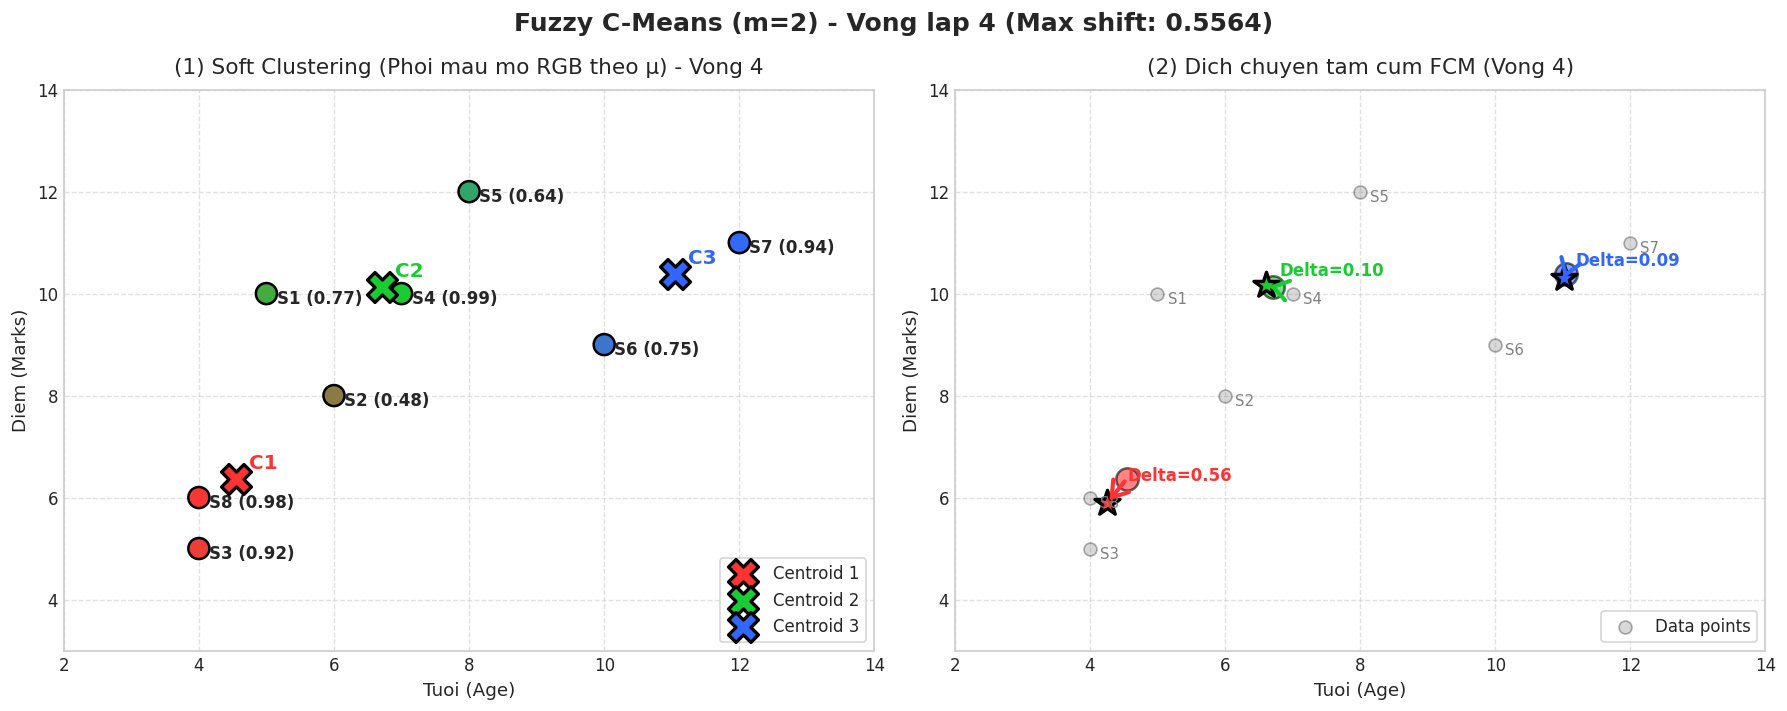


--- [FCM Vong lap 5] --- (Do dich chuyen tam lon nhat = 0.1929)
Sinh vien     Age   Marks  Dist C1  Dist C2  Dist C3  μ1 (C1)  μ2 (C2)  μ3 (C3)    Σ μ
       S1  5.0000 10.0000   4.1750   1.6185   6.0308   0.1229   0.8181   0.0589 1.0000
       S2  6.0000  8.0000   2.7352   2.2515   5.5259   0.3675   0.5424   0.0900 1.0000
       S3  4.0000  5.0000   0.9280   5.7890   8.8003   0.9645   0.0248   0.0107 1.0000
       S4  7.0000 10.0000   4.9396   0.4245   4.0345   0.0073   0.9819   0.0109 1.0000
       S5  8.0000 12.0000   7.1637   2.3003   3.4669   0.0668   0.6480   0.2852 1.0000
       S6 10.0000  9.0000   6.5296   3.5855   1.6566   0.0504   0.1671   0.7826 1.0000
       S7 12.0000 11.0000   9.2757   5.4541   1.2001   0.0157   0.0455   0.9388 1.0000
       S8  4.0000  6.0000   0.2798   4.9171   8.2365   0.9956   0.0032   0.0011 1.0000
Tam cum          Toa do cu         Toa do moi Do dich chuyen
     C1   (4.2578, 5.8915)   (4.1542, 5.7288)         0.1929
     C2  (6.6098, 10.1673)  (6

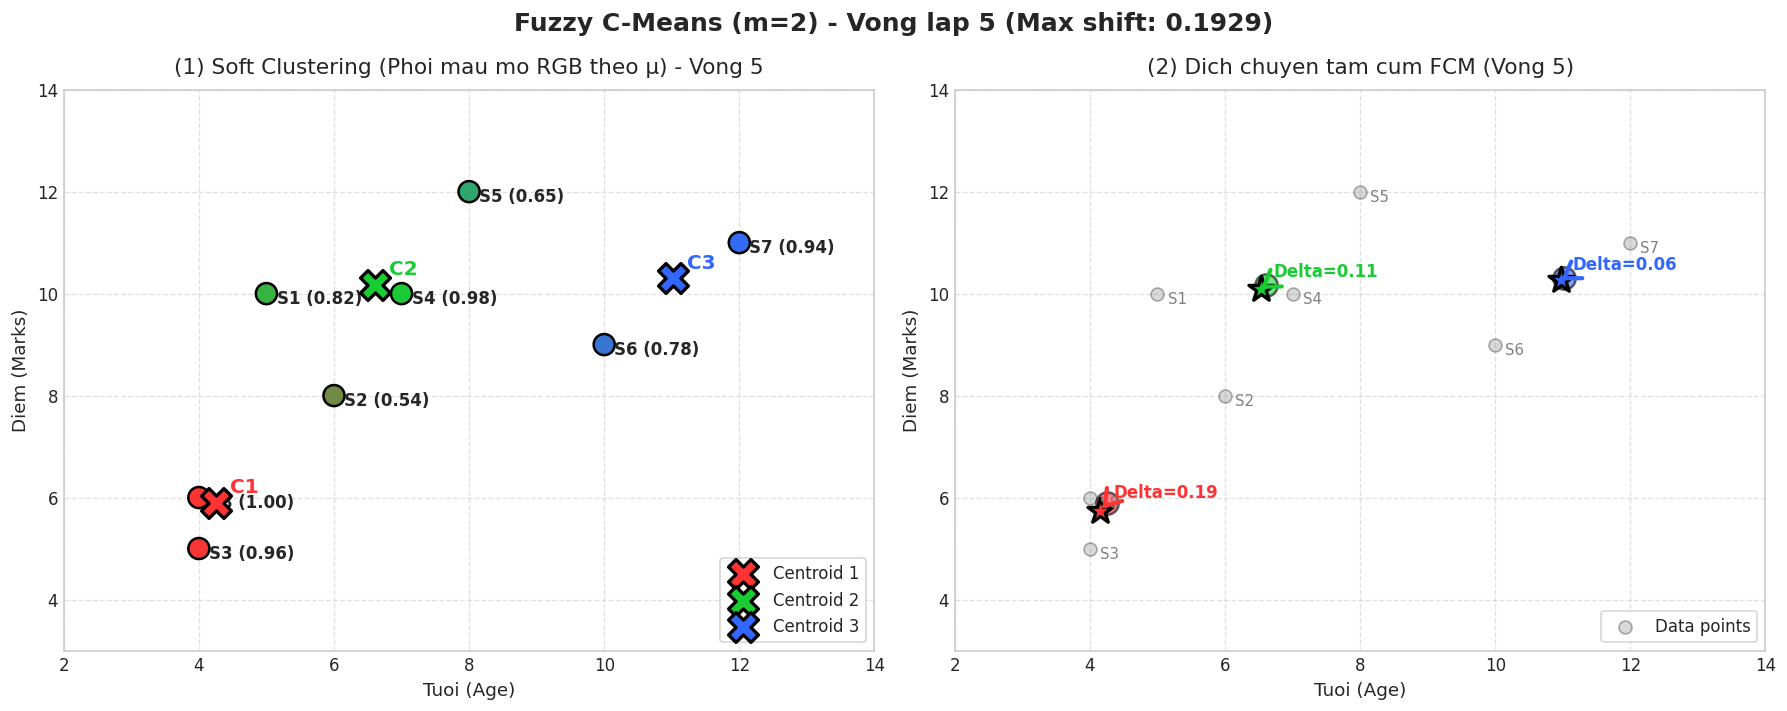


--- [FCM Vong lap 6] --- (Do dich chuyen tam lon nhat = 0.0866)
Sinh vien     Age   Marks  Dist C1  Dist C2  Dist C3  μ1 (C1)  μ2 (C2)  μ3 (C3)    Σ μ
       S1  5.0000 10.0000   4.3541   1.5315   5.9819   0.1040   0.8409   0.0551 1.0000
       S2  6.0000  8.0000   2.9267   2.1592   5.4660   0.3201   0.5881   0.0918 1.0000
       S3  4.0000  5.0000   0.7450   5.6866   8.7379   0.9762   0.0168   0.0071 1.0000
       S4  7.0000 10.0000   5.1324   0.4805   3.9848   0.0086   0.9772   0.0142 1.0000
       S5  8.0000 12.0000   7.3565   2.4082   3.4468   0.0672   0.6268   0.3060 1.0000
       S6 10.0000  9.0000   6.6988   3.6395   1.5951   0.0454   0.1538   0.8008 1.0000
       S7 12.0000 11.0000   9.4521   5.5459   1.2624   0.0167   0.0484   0.9349 1.0000
       S8  4.0000  6.0000   0.3119   4.8115   8.1748   0.9944   0.0042   0.0014 1.0000
Tam cum          Toa do cu         Toa do moi Do dich chuyen
     C1   (4.1542, 5.7288)   (4.1206, 5.6752)         0.0633
     C2  (6.5287, 10.0935)  (6

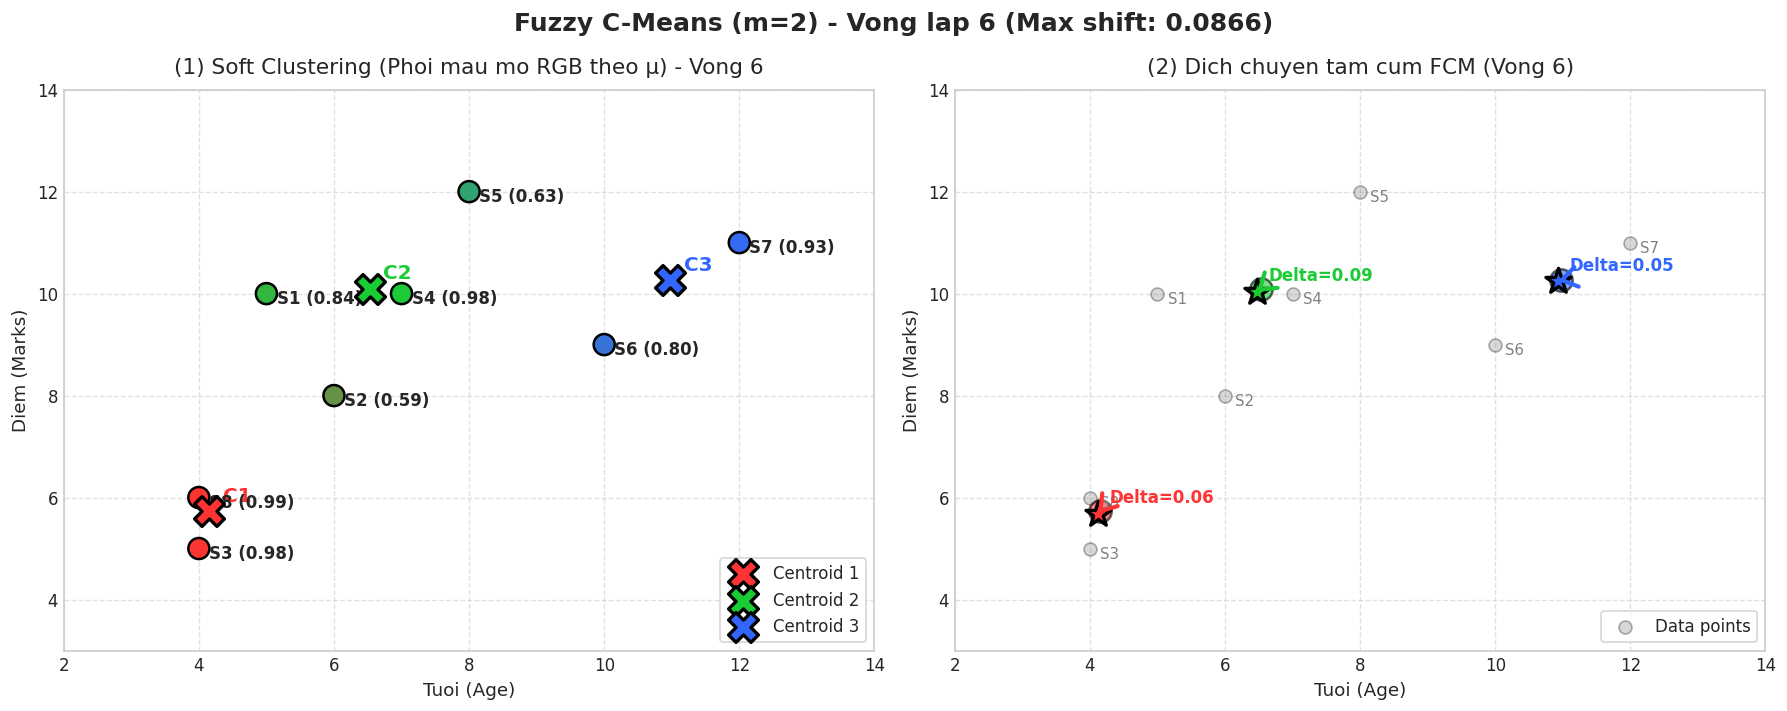

==> FUZZY C-MEANS DA HOI TU TAI VONG LAP 6 (max shift = 0.0866 < eps = 0.1)!


In [4]:
def run_fuzzy_c_means(data, student_names, initial_centers, m=2, eps=0.1, max_iter=20):
    print("===============================================================")
    print("       THUC THI FUZZY C-MEANS (FCM) - C=3, m=2, eps=0.1")
    print("===============================================================")
    
    centers = np.copy(initial_centers)
    N, C = len(data), len(centers)
    
    colors_base = np.array([
        [1.0, 0.2, 0.2], # Cum 1: Do
        [0.1, 0.8, 0.2], # Cum 2: Luc
        [0.2, 0.4, 1.0]  # Cum 3: Lam
    ])
    
    for it in range(1, max_iter + 1):
        # 1. Tinh ma tran khoang cach
        dist = np.zeros((N, C))
        for j in range(N):
            for i in range(C):
                dist[j, i] = np.linalg.norm(data[j] - centers[i])
                
        # 2. Tinh ma tran do thuoc U
        u = np.zeros((N, C))
        for j in range(N):
            zero_dist_idx = np.where(dist[j] < 1e-9)[0]
            if len(zero_dist_idx) > 0:
                for i in range(C):
                    u[j, i] = 1.0 if i == zero_dist_idx[0] else 0.0
            else:
                inv_sq = 1.0 / (dist[j] ** 2)
                u[j] = inv_sq / np.sum(inv_sq)
                
        # 3. Cap nhat tam cum
        new_centers = np.zeros_like(centers)
        for i in range(C):
            weights = u[:, i] ** m
            new_centers[i] = np.sum(weights[:, None] * data, axis=0) / np.sum(weights)
            
        # Kiem tra do lech tam lon nhat
        centroid_shifts = np.linalg.norm(new_centers - centers, axis=1)
        max_shift = np.max(centroid_shifts)
        
        print(f"\n--- [FCM Vong lap {it}] --- (Do dich chuyen tam lon nhat = {max_shift:.4f})")
        df_fcm = pd.DataFrame({
            'Sinh vien': student_names,
            'Age': data[:, 0],
            'Marks': data[:, 1],
            'Dist C1': dist[:, 0],
            'Dist C2': dist[:, 1],
            'Dist C3': dist[:, 2],
            'μ1 (C1)': u[:, 0],
            'μ2 (C2)': u[:, 1],
            'μ3 (C3)': u[:, 2],
            'Σ μ': np.sum(u, axis=1)
        })
        print(df_fcm.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
        
        # Bang cap nhat tam
        df_center_update = pd.DataFrame({
            'Tam cum': ['C1', 'C2', 'C3'],
            'Toa do cu': [f"({centers[i,0]:.4f}, {centers[i,1]:.4f})" for i in range(C)],
            'Toa do moi': [f"({new_centers[i,0]:.4f}, {new_centers[i,1]:.4f})" for i in range(C)],
            'Do dich chuyen': [f"{centroid_shifts[i]:.4f}" for i in range(C)]
        })
        print(df_center_update.to_string(index=False))
        
        # VE 2 BIEU DO SIDE-BY-SIDE
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))
        fig.suptitle(f"Fuzzy C-Means (m=2) - Vong lap {it} (Max shift: {max_shift:.4f})", fontsize=15, fontweight='bold', y=0.98)
        
        # Do thi 1: Soft Clustering Representation (Continuous RGB Blending)
        ax1 = axes[0]
        point_colors = np.dot(u, colors_base) # shape (N, 3)
        point_colors = np.clip(point_colors, 0.0, 1.0)
        
        ax1.scatter(data[:, 0], data[:, 1], s=160, c=point_colors, edgecolors='black', linewidths=1.5, zorder=3)
        for i in range(C):
            ax1.scatter(centers[i, 0], centers[i, 1], s=320, color=colors_base[i], marker='X', edgecolors='black', linewidths=2, label=f'Centroid {i+1}', zorder=4)
            ax1.text(centers[i, 0] + 0.2, centers[i, 1] + 0.2, f'C{i+1}', fontsize=12, fontweight='bold', color=colors_base[i])
            
        for j in range(N):
            dom_cluster = np.argmax(u[j]) + 1
            max_u = u[j, dom_cluster - 1]
            ax1.text(data[j, 0] + 0.15, data[j, 1] - 0.2, f"{student_names[j]} ({max_u:.2f})", fontsize=10, fontweight='bold')
            
        ax1.set_title(f"(1) Soft Clustering (Phoi mau mo RGB theo μ) - Vong {it}", fontsize=13, pad=10)
        ax1.set_xlabel("Tuoi (Age)", fontsize=11)
        ax1.set_ylabel("Diem (Marks)", fontsize=11)
        ax1.set_xlim(2, 14)
        ax1.set_ylim(3, 14)
        ax1.legend(loc='lower right', frameon=True)
        ax1.grid(True, linestyle='--', alpha=0.6)
        
        # Do thi 2: Centroid Shift Trajectory
        ax2 = axes[1]
        ax2.scatter(data[:, 0], data[:, 1], s=60, color='gray', alpha=0.3, edgecolors='black', label='Data points')
        for j in range(N):
            ax2.text(data[j, 0] + 0.15, data[j, 1] - 0.2, student_names[j], fontsize=9, color='gray')
            
        for i in range(C):
            ax2.scatter(centers[i, 0], centers[i, 1], s=180, color=colors_base[i], marker='o', edgecolors='black', linewidths=1.5, alpha=0.6, label=f'Old C{i+1}' if it==1 else "")
            ax2.scatter(new_centers[i, 0], new_centers[i, 1], s=250, color=colors_base[i], marker='*', edgecolors='black', linewidths=2, label=f'New C{i+1}' if it==1 else "")
            
            dx = new_centers[i, 0] - centers[i, 0]
            dy = new_centers[i, 1] - centers[i, 1]
            d_shift = centroid_shifts[i]
            if d_shift > 1e-4:
                ax2.annotate('', xy=(new_centers[i, 0], new_centers[i, 1]),
                             xytext=(centers[i, 0], centers[i, 1]),
                             arrowprops=dict(arrowstyle="->,head_width=0.4,head_length=0.6", color=colors_base[i], lw=2.5, mutation_scale=15))
                mid_x = (centers[i, 0] + new_centers[i, 0]) / 2
                mid_y = (centers[i, 1] + new_centers[i, 1]) / 2
                ax2.text(mid_x + 0.15, mid_y + 0.2, f'Delta={d_shift:.2f}', fontsize=10, color=colors_base[i], fontweight='bold')
            else:
                ax2.text(centers[i, 0] + 0.2, centers[i, 1] - 0.3, "Khong doi", fontsize=10, color=colors_base[i], fontstyle='italic')
                
        ax2.set_title(f"(2) Dich chuyen tam cum FCM (Vong {it})", fontsize=13, pad=10)
        ax2.set_xlabel("Tuoi (Age)", fontsize=11)
        ax2.set_ylabel("Diem (Marks)", fontsize=11)
        ax2.set_xlim(2, 14)
        ax2.set_ylim(3, 14)
        ax2.legend(loc='lower right', frameon=True)
        ax2.grid(True, linestyle='--', alpha=0.6)
        
        plt.tight_layout()
        plt.show()
        
        # Kiem tra tieu chi hoi tu
        if max_shift < eps:
            print(f"==> FUZZY C-MEANS DA HOI TU TAI VONG LAP {it} (max shift = {max_shift:.4f} < eps = {eps})!")
            break
            
        centers = np.copy(new_centers)
        
    return centers, u

fcm_final_centers, fcm_final_u = run_fuzzy_c_means(data, student_names, initial_centroids, m=2, eps=0.1, max_iter=20)


## 2.c. So sánh hiệu năng và kết quả giữa K-Means và Fuzzy C-Means

Dựa trên kết quả thu được từ Bài 1 và Bài 2, ta tiến hành so sánh toàn diện K-Means (Euclidean & Manhattan) và Fuzzy C-Means (FCM):

### 1. Điểm biên và Gán nhãn mềm (Soft assignments) vs Biên cứng (Hard boundaries)
- **Trong K-Means (Hard Clustering):**
  - Mỗi điểm bắt buộc phải thuộc dứt khoát 100% vào một cụm duy nhất (nhận giá trị rời rạc 0 hoặc 1).
  - Điển hình là điểm **$S_2(6, 8)$** và **$S_1(5, 10)$**:
    - Ở Vòng lặp 1 của K-Means, $S_2$ cách đều $C_1$ và $C_2$ ($d=2.2361$), thuật toán buộc phải dùng quy ước hòa (tie-break) để ép $S_2$ về $C_1$.
    - Ở Vòng lặp 2 của K-Means Euclidean, $S_1$ có khoảng cách tới Cụm 1 ($2.7613$) và Cụm 2 ($2.6926$) suýt soát nhau, nhưng $S_1$ bị chuyển hoàn toàn sang Cụm 2.
    - Điều này làm mất đi thông tin về sự không chắc chắn (uncertainty) tại vùng giáp ranh giữa các cụm.
- **Trong Fuzzy C-Means (Soft Clustering):**
  - Mọi điểm đều có độ thuộc liên tục $u_{ij} \in [0, 1]$.
  - Điểm $S_2(6, 8)$ thể hiện bản chất điểm biên: $\mu_1 = 47.37\%, \mu_2 = 47.37\%, \mu_3 = 5.26\%$.
  - Điểm $S_5(8, 12)$ có $\mu_2 = 59.57\%, \mu_1 = 22.91\%, \mu_3 = 17.52\%$.
  - Nhờ vậy, người phân tích thấy rõ được mức độ tự tin khi phân loại sinh viên, phù hợp với các bài toán thực tế khi ranh giới giữa các nhóm không phân tách tuyệt đối.

---

### 2. Tốc độ hội tụ (Convergence Rate)
| Thuật toán | Tiêu chí dừng | Số vòng lặp hội tụ | Đánh giá tốc độ |
|:---|:---|:---:|:---|
| **K-Means (Manhattan)** | Phân cụm không đổi | **2** | Rất nhanh (do không gian tìm kiếm rời rạc) |
| **K-Means (Euclidean)** | Phân cụm không đổi | **3** | Rất nhanh |
| **Fuzzy C-Means ($m=2$)** | $\max_i \|C_i^{(k)} - C_i^{(k-1)}\| < 0.1$ | **6** | Hội tụ chậm hơn, biến thiên liên tục mượt mà |

*Nhận xét:* K-Means hội tụ rất nhanh vì không gian trạng thái các phép gán cụm là hữu hạn ($3^8$ cấu hình). Ngược lại, FCM tối ưu hàm mục tiêu khả vi liên tục trong không gian thực, các tâm di chuyển dần dần theo gradient trọng số mờ nên cần nhiều bước lặp hơn để đạt ngưỡng sai số $\epsilon = 0.1$.

---

### 3. Tọa độ tâm cụm cuối cùng (Final Cluster Centers)

| Cụm | K-Means (Manhattan) | K-Means (Euclidean) | Fuzzy C-Means ($m=2, \epsilon=0.1$) |
|:---:|:---:|:---:|:---:|
| **Cluster 1** | $(4.75, 7.25)$ | $(4.67, 6.33)$ | **$(4.12, 5.68)$** |
| **Cluster 2** | $(8.33, 10.33)$ | $(6.67, 10.67)$ | **$(6.47, 10.03)$** |
| **Cluster 3** | $(12.00, 11.00)$ | $(11.00, 10.00)$ | **$(10.93, 10.25)$** |

**Phân tích sự khác biệt về tọa độ tâm:**
- Tâm Cụm 1 của FCM $(4.12, 5.68)$ bị kéo về gần nhóm sinh viên có tuổi và điểm thấp $\{S_3(4, 5), S_8(4, 6)\}$ hơn so với K-Means, vì trong FCM các điểm này có độ thuộc cụm 1 rất áp đảo ($u_{13} \approx 0.84, u_{18} \approx 0.88$).
- Tâm Cụm 2 của FCM $(6.47, 10.03)$ có vị trí trung hòa giữa các điểm $\{S_1, S_4, S_5\}$.
- Tâm Cụm 3 của FCM $(10.93, 10.25)$ gần như tương đồng với K-Means Euclidean $(11.00, 10.00)$, đại diện chuẩn xác cho nhóm điểm cao $\{S_6(10, 9), S_7(12, 11)\}$.


=== BANG TONG HOP TAM CUM CUOI CUNG ===
      Cum K-Means (Manhattan) K-Means (Euclidean) FCM (m=2, eps=0.1)
Cluster 1    (4.7500, 7.2500)    (4.6667, 6.3333)   (4.1542, 5.7288)
Cluster 2   (8.3333, 10.3333)   (6.6667, 10.6667)  (6.5287, 10.0935)
Cluster 3  (12.0000, 11.0000)  (11.0000, 10.0000) (10.9762, 10.2614)


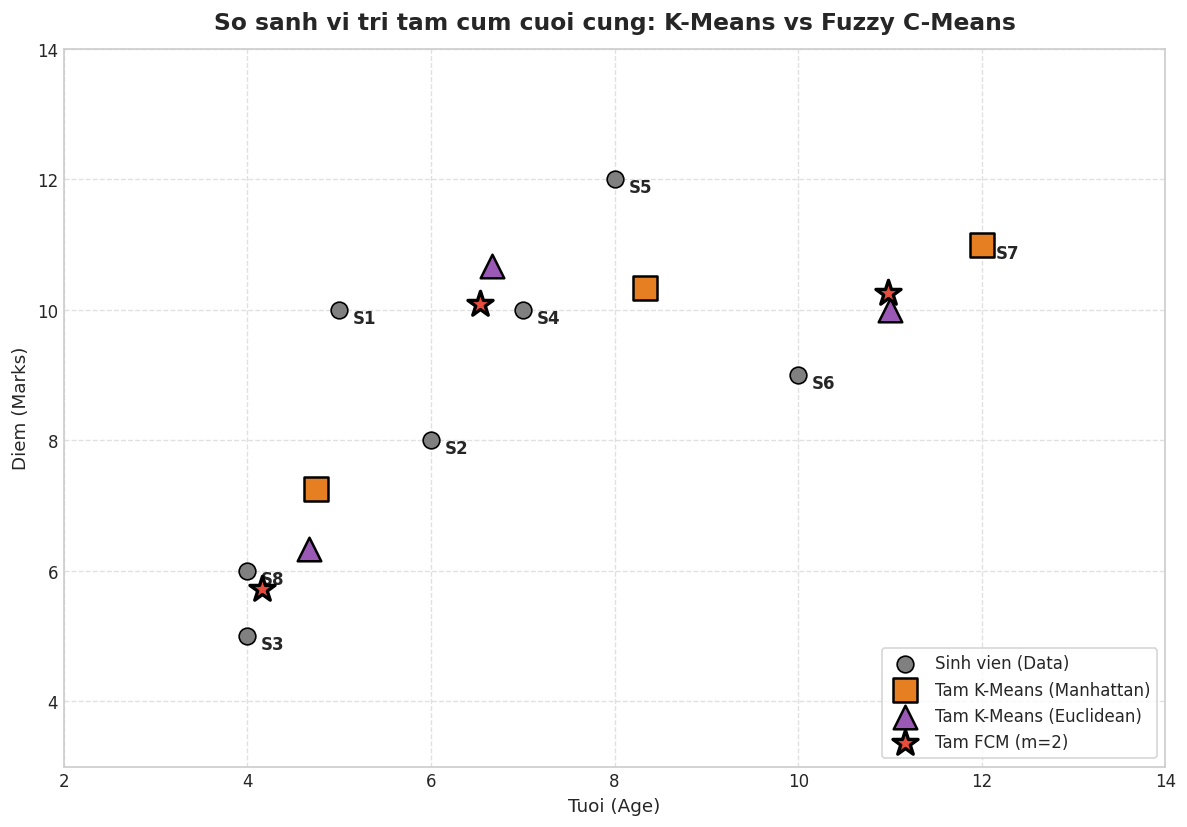

In [5]:
# Bang tong hop so sanh tam cum cuoi cung
df_compare_centers = pd.DataFrame({
    'Cum': ['Cluster 1', 'Cluster 2', 'Cluster 3'],
    'K-Means (Manhattan)': ['(4.7500, 7.2500)', '(8.3333, 10.3333)', '(12.0000, 11.0000)'],
    'K-Means (Euclidean)': ['(4.6667, 6.3333)', '(6.6667, 10.6667)', '(11.0000, 10.0000)'],
    'FCM (m=2, eps=0.1)': [f"({fcm_final_centers[i,0]:.4f}, {fcm_final_centers[i,1]:.4f})" for i in range(3)]
})
print("=== BANG TONG HOP TAM CUM CUOI CUNG ===")
print(df_compare_centers.to_string(index=False))

# Do thi so sanh tam cum cuoi cung cua cac phuong phap
plt.figure(figsize=(10, 7))
plt.scatter(data[:, 0], data[:, 1], s=100, color='gray', edgecolors='black', label='Sinh vien (Data)', zorder=2)
for i in range(len(data)):
    plt.text(data[i, 0] + 0.15, data[i, 1] - 0.2, student_names[i], fontsize=10, fontweight='bold')

km_man_c = np.array([[4.75, 7.25], [8.3333, 10.3333], [12.0, 11.0]])
km_euc_c = np.array([[4.6667, 6.3333], [6.6667, 10.6667], [11.0, 10.0]])

plt.scatter(km_man_c[:, 0], km_man_c[:, 1], s=200, marker='s', color='#E67E22', edgecolors='black', linewidths=1.5, label='Tam K-Means (Manhattan)', zorder=3)
plt.scatter(km_euc_c[:, 0], km_euc_c[:, 1], s=200, marker='^', color='#9B59B6', edgecolors='black', linewidths=1.5, label='Tam K-Means (Euclidean)', zorder=3)
plt.scatter(fcm_final_centers[:, 0], fcm_final_centers[:, 1], s=250, marker='*', color='#E74C3C', edgecolors='black', linewidths=2, label='Tam FCM (m=2)', zorder=4)

plt.title("So sanh vi tri tam cum cuoi cung: K-Means vs Fuzzy C-Means", fontsize=14, fontweight='bold', pad=12)
plt.xlabel("Tuoi (Age)", fontsize=11)
plt.ylabel("Diem (Marks)", fontsize=11)
plt.xlim(2, 14)
plt.ylim(3, 14)
plt.legend(loc='lower right', frameon=True, fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
